# **Proyecto Final · Machine Learning II**
## **Happy Cow Ice Cream: predicción de sabores *top seller* en el segmento local:**

### **1.1 Contexto del caso**

Mary Schroeder, CEO de Happy Cow Ice Cream, enfrenta un reto de posicionamiento: su marca es percibida como un producto para expatriados o nichos muy específicos, y su objetivo es penetrar el mercado local chino de Hong Kong. Para lograrlo, eligió la tienda de la Universidad de Hong Kong (HKU) como punto de prueba, dado que el 80\% de sus clientes son consumidores locales —estudiantes y personal universitario.

El desafío operativo es concreto: el espacio de almacenamiento es reducido y el helado es un producto perecedero. Esto significa que una decisión equivocada sobre qué sabores incluir en carta se traduce directamente en merma, costos de obsolescencia y pérdida de oportunidad comercial. Mary necesita una herramienta que le permita anticipar qué sabores van a rendir bien antes de comprometer su inventario.

El elemento diferenciador de este proyecto es la incorporación de la **Medicina Tradicional China (MTC)** como marco conceptual. El consumidor local de HKU no elige un helado únicamente por su sabor: sus decisiones de consumo están influenciadas por creencias culturales sobre el equilibrio del cuerpo y el efecto de los alimentos según la temporada. La MTC clasifica los alimentos por su naturaleza térmica (Frío, Neutro, Cálido), su función energética (generar fluidos, drenar humedad, tónico) y los asocia con condiciones climáticas estacionales denominadas **los seis males**: Viento, Calor de Verano, Humedad, Sequedad y Frío.

### **Pregunta analítica:**
**¿Qué características del sabor, del contexto académico y de la temporada climática ayudan a predecir si un sabor estará entre los más vendidos del segmento local?**

### **1.2 Problema de negocio claramente definido**

Happy Cow no cuenta con un sistema que le permita anticipar la demanda por sabor según el contexto estacional y académico. Como resultado, las decisiones de portafolio se toman con base en la intuición del equipo operativo, lo que genera dos problemas recurrentes:

- **Merma por sobrestock:** sabores que se preparan pero no se venden dentro del período útil.
- **Oportunidad perdida:** sabores demandados que no estaban disponibles porque el espacio fue asignado a otros productos.

El problema analítico que se plantea es el siguiente:

> *Dado el contexto de un día específico —definido por su posición en el calendario académico de HKU y por el mal estacional predominante según la MTC— y dados los atributos culturales de un sabor, ¿es posible predecir si ese sabor estará entre los cinco más vendidos del segmento local ese día?*

### **1.3 Impacto esperado en la organización**

La implementación de este modelo tiene tres impactos concretos para Happy Cow:

**Reducción de merma operativa.** Al anticipar qué sabores tienen mayor probabilidad de ser top sellers en un día dado, Mary puede ajustar su preparación de inventario con mayor precisión, reduciendo la cantidad de producto que no se vende dentro de su período de vida útil.

**Mejora en la tasa de conversión del segmento local.** Una carta alineada con las preferencias culturales y estacionales del consumidor local incrementa la probabilidad de que un estudiante o miembro del personal encuentre un sabor que le resulte atractivo según su contexto cultural, lo que se traduce en mayor frecuencia de compra.

**Validación de la hipótesis MTC como driver de compra.** Si las variables de perfil MTC aparecen como predictores relevantes en el modelo, se obtiene evidencia cuantitativa de que la alineación cultural del portafolio no es solo una intuición sino un factor real de desempeño comercial. Esto fortalece la estrategia de diferenciación de la marca frente al mercado local.

### **1.4 Identificación de stakeholders**

| Stakeholder | Rol en el proyecto | Interés principal |
|---|---|---|
| Mary Schroeder (CEO) | Tomadora de decisiones operativas | Saber qué sabores poner en carta cada día sin generar merma |
| Equipo operativo de la tienda HKU | Usuario directo del modelo | Recibir recomendaciones claras y accionables |
| Proveedores de ingredientes | Afectados por la planificación de inventario | Previsibilidad en los pedidos |
| Consumidores locales (Students y Staff) | Fuente de los datos y beneficiarios indirectos | Encontrar una oferta culturalmente relevante |


> **Segmento objetivo:** `Student + Staff`  
> **Segmento excluido del modelo principal:** `Tourism`


## **1. Carga de librerías:**

En esta sección se importan las librerías que se utilizarán a lo largo del desarrollo del proyecto. Estas herramientas permiten realizar la manipulación y transformación de datos, construir visualizaciones para el análisis exploratorio y apoyar la preparación de la base final que servirá para las etapas posteriores de modelado.

En particular, se incluyen librerías para trabajar con estructuras tabulares, operaciones numéricas, gráficos estadísticos y configuración general del entorno de análisis.

In [158]:
import warnings

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from matplotlib.ticker import PercentFormatter

warnings.filterwarnings("ignore")

## **2. Carga de datos crudos:**

En esta sección se realiza la carga inicial de los datos diarios de ventas a partir del archivo fuente original. El propósito de este paso es incorporar la información tal como fue registrada en la operación, conservando la separación por segmento para mantener trazabilidad sobre el origen de los datos y facilitar el proceso posterior de integración.

Para este proyecto, las hojas utilizadas corresponden a las ventas diarias de **Student** y **Staff**, que conforman el segmento local de interés para el caso de negocio. Trabajar primero con estas fuentes en su estado original permite verificar la estructura de cada hoja, identificar posibles diferencias de formato y asegurar que la construcción de la base analítica se apoye en insumos consistentes desde el inicio.

Adicionalmente, en esta etapa se corrige un problema de nomenclatura detectado en la hoja de **Staff**, donde la columna de fecha aparece nombrada como `Product` en lugar de `Date`. Esta corrección se realiza al momento de la carga para estandarizar la estructura entre ambas fuentes y evitar errores en las etapas posteriores de limpieza, transformación y consolidación de la información.

In [159]:
FILE = 'icecream1.xlsx'

df_student = pd.read_excel(FILE, sheet_name='student daily')
df_staff   = pd.read_excel(FILE, sheet_name='staff daily')

# Renombrar columna de fecha en staff
df_staff = df_staff.rename(columns={'Product': 'Date'})

print('Student daily:', df_student.shape)
print('Staff daily:  ', df_staff.shape)
print()
print('Rango de fechas:', df_student['Date'].iloc[0], '→', df_student['Date'].iloc[-1])

Student daily: (183, 33)
Staff daily:   (183, 30)

Rango de fechas: Sat 1st Apr 2017 → Sat 30th Sep 2017


In [160]:
df_student.head(3)

,Date,1 Toppings St,Apricot ST,Banana Caramel St,Chai Tea st,Cherry Almond Fudge st,Chocolate St,Coffee St,Cus. IC Sand St,Double Scoop ST,...,S. Caramel St,Single Scoop ST,Stamp Card REDEEM ST,Strawberry St,Triple Scoop ST,Tub Ice Cream ST,Up 3 Toppings ST,Vanilla Bean St,Waffle Cone St,YY Seasame St
0,Sat 1st Apr 2017,0,0,26.0,104.0,0.0,156.0,26.0,0,-65,...,390.0,0,0,156.0,-26,0,0,26.0,155.0,0.0
1,Sun 2nd Apr 2017,0,0,0.0,0.0,0.0,0.0,0.0,0,0,...,0.0,0,0,0.0,0,0,0,0.0,0.0,0.0
2,Mon 3rd Apr 2017,0,0,0.0,52.0,52.0,130.0,52.0,0,-260,...,806.0,0,0,390.0,0,0,0,26.0,155.0,26.0


In [161]:
df_staff.head(3)

,Date,S. Caramel Staff,Mango Staff,Chocolate Staff,Pure Coconut Staff,Mint Choco Staff,Strawberry Staff,Waffle Cone Staff,Chai Tea Staff,Hezelnut Staff,...,Lime Coconut Staff,Pistachio Staff,Ginger Staff,1 Topping Staff,Cus IC Sand Staff,3 Topping Staff,Single Scoop Staff,Tub Staff,Triple Scoop Staff,Double Scoop Staff
0,Sat 1st Apr 2017,0.0,30.0,30.0,60.0,30.0,0.0,12.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
1,Sun 2nd Apr 2017,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
2,Mon 3rd Apr 2017,0.0,60.0,60.0,30.0,0.0,0.0,6.0,0.0,60.0,...,0,0,0,0,0,0,0,0,0,-15




*   La carga de datos confirma que ambas hojas contienen información diaria para el mismo horizonte temporal, con registros comprendidos entre el **1 de abril de 2017** y el **30 de septiembre de 2017**. Esto es importante porque valida que las fuentes utilizadas comparten una ventana de análisis común y, por tanto, pueden integrarse de forma coherente en una base unificada para el segmento local.

*   También se observa que la hoja de **Student** contiene **183 filas y 33 columnas**, mientras que la hoja de **Staff** presenta **183 filas y 30 columnas**. Esta diferencia en el número de columnas sugiere que los catálogos o formatos de registro no son idénticos entre segmentos, lo cual es un hallazgo relevante desde el punto de vista del negocio y de la preparación de datos: antes de consolidar ventas locales, será necesario homologar nombres, identificar sabores comparables y separar correctamente los productos que sí representan sabores de aquellos que corresponden a formatos, toppings u otros conceptos operativos.
*   En términos metodológicos, esta revisión inicial permite concluir que la base cruda es suficientemente consistente para avanzar hacia la etapa de limpieza y transformación, pero también deja claro que la integración no puede hacerse de forma automática sin una revisión cuidadosa de estructura y nomenclatura. Por ello, esta fase cumple una función crítica: asegurar que el análisis posterior se construya sobre una base alineada con la realidad operativa del caso.

## **3. Selección de sabores válidos:**

No todas las columnas del Excel representan sabores reales.  
Por eso, en esta etapa se separan los **sabores comercializables** de los **formatos, toppings, vales o redenciones**.

### Se excluyen elementos como:
- `Single Scoop`
- `Double Scoop`
- `Triple Scoop`
- `Tub`
- toppings
- vouchers
- tarjetas o redenciones

### Razón
Estos elementos no representan sabores y, si se incluyeran, podrían distorsionar el problema analítico y el cálculo del objetivo.


In [162]:
# Sabores válidos — Student
sabores_student = {
    'Apricot ST'             : 'Apricot',
    'Banana Caramel St'      : 'Banana Caramel',
    'Chai Tea st'            : 'Chai Tea',
    'Cherry Almond Fudge st' : 'Cherry Almond Fudge',
    'Chocolate St'           : 'Chocolate',
    'Coffee  St'             : 'Coffee',
    'Ginger St'              : 'Ginger',
    'Green Tea St'           : 'Green Tea',
    'Hazelnut St'            : 'Hazelnut',
    'Lime Coconut ST'        : 'Lime Coconut',
    'Mango St'               : 'Mango',
    'Mint Choco  St'         : 'Mint Choco',
    'Pina Colada St'         : 'Pina Colada',
    'Pistachio St'           : 'Pistachio',
    'Pure Coco . St'         : 'Pure Coconut',
    'Red Bean St'            : 'Red Bean',
    'S. Caramel St'          : 'Salted Caramel',
    'Strawberry St'          : 'Strawberry',
    'Vanilla Bean St'        : 'Vanilla Bean',
    'YY Seasame St'          : 'YY Sesame',
}

# Sabores válidos — Staff
sabores_staff = {
    'Apricot Staff'          : 'Apricot',
    'Banana Staff'           : 'Banana Caramel',
    'Chai Tea Staff'         : 'Chai Tea',
    'Cherry Alm Staff'       : 'Cherry Almond Fudge',
    'Chocolate Staff'        : 'Chocolate',
    'Coffee Staff'           : 'Coffee',
    'Ginger Staff'           : 'Ginger',
    'Green Tea Staff'        : 'Green Tea',
    'Hezelnut Staff'         : 'Hazelnut',
    'Lime Coconut Staff'     : 'Lime Coconut',
    'Mango Staff'            : 'Mango',
    'Mint Choco Staff'       : 'Mint Choco',
    'Pina Colada Staff'      : 'Pina Colada',
    'Pistachio Staff'        : 'Pistachio',
    'Pure Coconut Staff'     : 'Pure Coconut',
    'Red Bean Staff'         : 'Red Bean',
    'S. Caramel Staff'       : 'Salted Caramel',
    'Strawberry Staff'       : 'Strawberry',
    'Vanilla Bean Staff'     : 'Vanilla Bean',
    'YY Seasame Staff'       : 'YY Sesame',
}

print('Sabores válidos definidos:', len(sabores_student))

Sabores válidos definidos: 20


**Resultado de la selección:**

Como resultado de este proceso, se definieron **20 sabores válidos** para el análisis. Esta decisión mejora la calidad de la base porque evita mezclar sabores con elementos que no representan una preferencia real del consumidor, como tamaños, toppings o mecanismos de redención.

Desde la perspectiva del negocio, esta depuración es importante porque permite que las comparaciones posteriores se hagan entre productos realmente sustituibles dentro del portafolio. En otras palabras, ayuda a que el análisis de ventas, el cálculo de `top_seller` y la interpretación del desempeño comercial se centren en sabores reales y no en componentes operativos del punto de venta.

## **4. Limpieza y consolidación del segmento local¨:**

En esta etapa se construye una medida única de ventas para el mercado local:

**Ventas locales = Ventas Student + Ventas Staff**

### Objetivo de este paso
Obtener una sola tabla con ventas por sabor para el segmento que realmente interesa en el problema de negocio.

### Decisión metodológica
Los dos segmentos se unifican porque ambos representan consumidores locales dentro del ecosistema de HKU.


In [163]:
# Filtrar y renombrar columnas
st = df_student[['Date'] + list(sabores_student.keys())].copy()
st = st.rename(columns=sabores_student)

sf = df_staff[['Date'] + list(sabores_staff.keys())].copy()
sf = sf.rename(columns=sabores_staff)

# Reemplazar negativos por 0 (son devoluciones/ajustes contables)
st[list(sabores_student.values())] = st[list(sabores_student.values())].clip(lower=0)
sf[list(sabores_staff.values())]   = sf[list(sabores_staff.values())].clip(lower=0)

# Combinar Student + Staff
sabores = list(sabores_student.values())
ventas_local = st.set_index('Date')[sabores] + sf.set_index('Date')[sabores]
ventas_local = ventas_local.reset_index()

print('Base ventas locales:', ventas_local.shape)
ventas_local.head()

Base ventas locales: (183, 21)


,Date,Apricot,Banana Caramel,Chai Tea,Cherry Almond Fudge,Chocolate,Coffee,Ginger,Green Tea,Hazelnut,...,Mango,Mint Choco,Pina Colada,Pistachio,Pure Coconut,Red Bean,Salted Caramel,Strawberry,Vanilla Bean,YY Sesame
0,Sat 1st Apr 2017,0,26.0,104.0,0.0,186.0,26.0,0,0.0,260.0,...,368.0,238.0,56.0,0,112.0,0.0,390.0,156.0,26.0,0.0
1,Sun 2nd Apr 2017,0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,...,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,Mon 3rd Apr 2017,0,0.0,52.0,52.0,190.0,52.0,0,0.0,346.0,...,294.0,338.0,30.0,0,368.0,0.0,806.0,390.0,26.0,56.0
3,Tue 4th Apr 2017,0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,...,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0
4,Wed 5th Apr 2017,0,234.0,26.0,0.0,450.0,0.0,0,52.0,104.0,...,350.0,536.0,0.0,0,632.0,0.0,710.0,208.0,26.0,26.0


## **5. Transformación a formato largo:**

La tabla original está en formato ancho: una columna por sabor.  
Para modelar mejor, se transforma a formato largo, donde cada fila representa una combinación de:

- fecha
- sabor
- ventas

### Unidad de análisis actual
**Una fila = un sabor en un día**


In [164]:
df_long = ventas_local.melt(id_vars='Date', var_name='sabor', value_name='ventas')
df_long = df_long.sort_values(['Date', 'sabor']).reset_index(drop=True)

print('Filas totales:', len(df_long))
print('Días únicos: ', df_long['Date'].nunique())
print('Sabores únicos:', df_long['sabor'].nunique())
df_long.head(10)

Filas totales: 3660
Días únicos:  183
Sabores únicos: 20


,Date,sabor,ventas
0,Fri 11th Aug 2017,Apricot,0.0
1,Fri 11th Aug 2017,Banana Caramel,26.0
2,Fri 11th Aug 2017,Chai Tea,52.0
3,Fri 11th Aug 2017,Cherry Almond Fudge,134.0
4,Fri 11th Aug 2017,Chocolate,26.0
5,Fri 11th Aug 2017,Coffee,30.0
6,Fri 11th Aug 2017,Ginger,0.0
7,Fri 11th Aug 2017,Green Tea,0.0
8,Fri 11th Aug 2017,Hazelnut,78.0
9,Fri 11th Aug 2017,Lime Coconut,0.0


## **6. Construcción de la variable objetivo:**

Se define la variable objetivo `top_seller`.

### Regla
Un sabor recibe valor **1** si está entre los **5 más vendidos** del segmento local en ese día.  
En caso contrario, recibe valor **0**.

### Interpretación
Esta variable permite convertir el problema de negocio en un problema de **clasificación binaria**:

- **1 = sabor destacado del día**
- **0 = sabor no destacado del día**


In [165]:
# La variable objetivo se construye por ranking diario de ventas.
# Se usa rank() en lugar de apply() para conservar 'Date' como columna
# y evitar que el groupby la convierta en índice.
df_long['rank_dia'] = (
    df_long.groupby('Date')['ventas']
    .rank(method='first', ascending=False)
)
df_long['top_seller'] = (df_long['rank_dia'] <= 5).astype(int)
df_long = df_long.drop(columns='rank_dia')

print('Distribución top_seller:')
print(df_long['top_seller'].value_counts())
print()
print('Proporción:', df_long['top_seller'].mean().round(2))

Distribución top_seller:
top_seller
0    2745
1     915
Name: count, dtype: int64

Proporción: 0.25


## **7. Creación de variables temporales:**

A partir de la fecha se generan variables que ayudan a capturar el contexto del consumo.

### Variables derivadas
- fecha en formato estándar
- día del año
- día de la semana
- mes

### Propósito
Estas variables permiten relacionar el comportamiento de ventas con la estacionalidad y con la dinámica temporal del negocio.


In [166]:
df_long['fecha'] = pd.to_datetime(df_long['Date'], format='%a %dst %b %Y', errors='coerce')
df_long['fecha'] = df_long['fecha'].fillna(
    pd.to_datetime(df_long['Date'], format='%a %dnd %b %Y', errors='coerce')).fillna(
    pd.to_datetime(df_long['Date'], format='%a %drd %b %Y', errors='coerce')).fillna(
    pd.to_datetime(df_long['Date'], format='%a %dth %b %Y', errors='coerce'))

df_long['dia_del_año']     = df_long['fecha'].dt.dayofyear
df_long['dia_de_semana']   = df_long['fecha'].dt.day_name()
df_long['mes']             = df_long['fecha'].dt.month

print('Fechas parseadas correctamente:', df_long['fecha'].notna().sum())
print('Fechas con error:', df_long['fecha'].isna().sum())
df_long[['Date','fecha','dia_del_año','dia_de_semana']].head()

Fechas parseadas correctamente: 3660
Fechas con error: 0


,Date,fecha,dia_del_año,dia_de_semana
0,Fri 11th Aug 2017,2017-08-11,223,Friday
1,Fri 11th Aug 2017,2017-08-11,223,Friday
2,Fri 11th Aug 2017,2017-08-11,223,Friday
3,Fri 11th Aug 2017,2017-08-11,223,Friday
4,Fri 11th Aug 2017,2017-08-11,223,Friday


## **8. Asignación del mal estacional según MTC:**

Con base en el caso de negocio y en el marco de la **Medicina Tradicional China (MTC)**, se asigna a cada observación un **mal estacional dominante** según el mes.

### Ejemplos
- `Wind`
- `Summer-Heat`
- `Dampness`
- `Dryness`
- `Cold`

### Importante
Esta variable **no proviene directamente del Excel**.  
Es una variable construida como parte del **feature engineering**, usando el contexto conceptual del caso.


In [167]:
# Fuente: Exhibit 2 — The Six Evils Related to Climate and Seasons
mal_estacional_map = {
    1:  'Cold',        # Enero   — Invierno
    2:  'Cold',        # Febrero — Invierno
    3:  'Wind',        # Marzo   — Primavera
    4:  'Wind',        # Abril   — Primavera
    5:  'Summer_Heat', # Mayo    — Verano temprano
    6:  'Summer_Heat', # Junio   — Verano
    7:  'Summer_Heat', # Julio   — Verano
    8:  'Dampness',    # Agosto  — Finales de verano
    9:  'Dampness',    # Septiembre — Finales de verano
    10: 'Dryness',     # Octubre — Otoño
    11: 'Dryness',     # Noviembre — Otoño
    12: 'Cold',        # Diciembre — Invierno
}

df_long['mal_estacional'] = df_long['mes'].map(mal_estacional_map)

print('Distribución mal estacional en el dataset:')
print(df_long['mal_estacional'].value_counts())

Distribución mal estacional en el dataset:
mal_estacional
Summer_Heat    1840
Dampness       1220
Wind            600
Name: count, dtype: int64


## **9. Asignación del periodo académico HKU:**

El comportamiento de compra puede cambiar según la carga académica de los estudiantes.  
Por eso, cada fecha se cruza con el calendario de HKU para asignar su periodo correspondiente.

### Periodos considerados
- `Teaching`
- `Reading`
- `Assessment`
- `Break`

### Propósito
Capturar si el contexto universitario influye en qué sabores se vuelven más fuertes en ventas.


In [168]:
def asignar_periodo(fecha):
    if pd.isna(fecha):
        return 'Unknown'
    # Segundo semestre 2016-2017
    if pd.Timestamp('2017-01-16') <= fecha <= pd.Timestamp('2017-04-28'):
        return 'Teaching'
    if pd.Timestamp('2017-04-29') <= fecha <= pd.Timestamp('2017-05-06'):
        return 'Reading'
    if pd.Timestamp('2017-05-07') <= fecha <= pd.Timestamp('2017-05-26'):
        return 'Assessment'
    # Verano
    if pd.Timestamp('2017-05-27') <= fecha <= pd.Timestamp('2017-08-31'):
        return 'Break'
    # Primer semestre 2017-2018
    if pd.Timestamp('2017-09-01') <= fecha <= pd.Timestamp('2017-11-30'):
        return 'Teaching'
    if pd.Timestamp('2017-12-01') <= fecha <= pd.Timestamp('2017-12-07'):
        return 'Reading'
    if pd.Timestamp('2017-12-08') <= fecha <= pd.Timestamp('2017-12-23'):
        return 'Assessment'
    return 'Break'

df_long['periodo_academico'] = df_long['fecha'].apply(asignar_periodo)

print('Distribución período académico:')
print(df_long['periodo_academico'].value_counts())

Distribución período académico:
periodo_academico
Break         1940
Teaching      1160
Assessment     400
Reading        160
Name: count, dtype: int64


## **10. Construcción de la tabla de atributos MTC por sabor:**

Cada sabor se representa mediante una tabla auxiliar con atributos teóricos inspirados en la MTC.

### Atributos asignados
- **naturaleza_sabor**: `Frío`, `Neutro`, `Cálido`
- **funcion_sabor**: por ejemplo `Generar fluidos`, `Drenar humedad`, `Tónico`
- **origen_sabor**: `Oriental` u `Occidental`

### Propósito
En lugar de usar el nombre del sabor como predictor, se usan sus atributos conceptuales.  
Esto hace que el modelo aprenda **patrones del perfil del sabor**, y no solo memorice nombres específicos.

### Nota metodológica
Esta tabla es una construcción manual y debe entenderse como una representación experta del producto, no como un dato observado directamente.


In [169]:
mtc_lookup = {
    'Ginger'              : ('Calido',  'Drenar_humedad',   'Oriental'),
    'Red Bean'            : ('Calido',  'Tonico',           'Oriental'),
    'Green Tea'           : ('Frio',    'Generar_fluidos',  'Oriental'),
    'YY Sesame'           : ('Neutro',  'Tonico',           'Oriental'),
    'Chai Tea'            : ('Calido',  'Drenar_humedad',   'Oriental'),
    'Lime Coconut'        : ('Frio',    'Generar_fluidos',  'Oriental'),
    'Pure Coconut'        : ('Frio',    'Generar_fluidos',  'Oriental'),
    'Mango'               : ('Frio',    'Generar_fluidos',  'Oriental'),
    'Pina Colada'         : ('Frio',    'Generar_fluidos',  'Occidental'),
    'Mint Choco'          : ('Frio',    'Generar_fluidos',  'Occidental'),
    'Chocolate'           : ('Calido',  'Tonico',           'Occidental'),
    'Coffee'              : ('Calido',  'Tonico',           'Occidental'),
    'Hazelnut'            : ('Calido',  'Tonico',           'Occidental'),
    'Vanilla Bean'        : ('Neutro',  'Tonico',           'Occidental'),
    'Salted Caramel'      : ('Neutro',  'Tonico',           'Occidental'),
    'Strawberry'          : ('Frio',    'Generar_fluidos',  'Occidental'),
    'Banana Caramel'      : ('Neutro',  'Tonico',           'Occidental'),
    'Apricot'             : ('Neutro',  'Generar_fluidos',  'Occidental'),
    'Cherry Almond Fudge' : ('Calido',  'Tonico',           'Occidental'),
    'Pistachio'           : ('Neutro',  'Tonico',           'Occidental'),
}

df_mtc = pd.DataFrame.from_dict(
    mtc_lookup, orient='index',
    columns=['naturaleza_sabor', 'funcion_sabor', 'origen_sabor']
).reset_index().rename(columns={'index': 'sabor'})

print(df_mtc)

                  sabor naturaleza_sabor    funcion_sabor origen_sabor
0                Ginger           Calido   Drenar_humedad     Oriental
1              Red Bean           Calido           Tonico     Oriental
2             Green Tea             Frio  Generar_fluidos     Oriental
3             YY Sesame           Neutro           Tonico     Oriental
4              Chai Tea           Calido   Drenar_humedad     Oriental
5          Lime Coconut             Frio  Generar_fluidos     Oriental
6          Pure Coconut             Frio  Generar_fluidos     Oriental
7                 Mango             Frio  Generar_fluidos     Oriental
8           Pina Colada             Frio  Generar_fluidos   Occidental
9            Mint Choco             Frio  Generar_fluidos   Occidental
10            Chocolate           Calido           Tonico   Occidental
11               Coffee           Calido           Tonico   Occidental
12             Hazelnut           Calido           Tonico   Occidental
13    

## **11. Integración de la base final para modelado:**

En este paso se unen todas las capas construidas hasta ahora:

- ventas por sabor,
- variable objetivo,
- variables temporales,
- contexto académico,
- variables MTC del clima,
- y atributos MTC del sabor.

### Resultado esperado
Una base final limpia, consistente y lista para la siguiente fase del proyecto:
**exploración analítica y modelado supervisado**.


In [170]:
df_model = df_long.merge(df_mtc, on='sabor', how='left')

# Seleccionar columnas finales
columnas_finales = [
    'fecha', 'sabor', 'ventas',
    'dia_del_año', 'dia_de_semana', 'periodo_academico', 'mal_estacional',
    'naturaleza_sabor', 'funcion_sabor', 'origen_sabor',
    'top_seller'
]

df_model = df_model[columnas_finales].sort_values(['fecha','sabor']).reset_index(drop=True)

print('Base de datos final:', df_model.shape)
print('Nulos:', df_model.isnull().sum().sum())
df_model.head(10)

Base de datos final: (3660, 11)
Nulos: 0


,fecha,sabor,ventas,dia_del_año,dia_de_semana,periodo_academico,mal_estacional,naturaleza_sabor,funcion_sabor,origen_sabor,top_seller
0,2017-04-01,Apricot,0.0,91,Saturday,Teaching,Wind,Neutro,Generar_fluidos,Occidental,0
1,2017-04-01,Banana Caramel,26.0,91,Saturday,Teaching,Wind,Neutro,Tonico,Occidental,0
2,2017-04-01,Chai Tea,104.0,91,Saturday,Teaching,Wind,Calido,Drenar_humedad,Oriental,0
3,2017-04-01,Cherry Almond Fudge,0.0,91,Saturday,Teaching,Wind,Calido,Tonico,Occidental,0
4,2017-04-01,Chocolate,186.0,91,Saturday,Teaching,Wind,Calido,Tonico,Occidental,1
5,2017-04-01,Coffee,26.0,91,Saturday,Teaching,Wind,Calido,Tonico,Occidental,0
6,2017-04-01,Ginger,0.0,91,Saturday,Teaching,Wind,Calido,Drenar_humedad,Oriental,0
7,2017-04-01,Green Tea,0.0,91,Saturday,Teaching,Wind,Frio,Generar_fluidos,Oriental,0
8,2017-04-01,Hazelnut,260.0,91,Saturday,Teaching,Wind,Calido,Tonico,Occidental,1
9,2017-04-01,Lime Coconut,0.0,91,Saturday,Teaching,Wind,Frio,Generar_fluidos,Oriental,0


## **12. Revisión exploratoria inicial de la base construida:**

Antes de entrenar modelos, se realiza una exploración básica para verificar:

- distribución de la variable objetivo,
- consistencia de las nuevas variables,
- comportamiento preliminar por contexto temporal,
- y calidad general de la base final.

### Objetivo
Confirmar que la base quedó coherente y dejar lista la transición hacia el **EDA formal** y el modelado.


In [171]:
print('=== Distribución de clases ===')
print(df_model['top_seller'].value_counts())
print()
print('=== Top sellers por mal estacional ===')
print(df_model.groupby('mal_estacional')['top_seller'].mean().round(2))
print()
print('=== Top sellers por naturaleza MTC ===')
print(df_model.groupby('naturaleza_sabor')['top_seller'].mean().round(2))
print()
print('=== Top sellers por periodo académico ===')
print(df_model.groupby('periodo_academico')['top_seller'].mean().round(2))

=== Distribución de clases ===
top_seller
0    2745
1     915
Name: count, dtype: int64

=== Top sellers por mal estacional ===
mal_estacional
Dampness       0.25
Summer_Heat    0.25
Wind           0.25
Name: top_seller, dtype: float64

=== Top sellers por naturaleza MTC ===
naturaleza_sabor
Calido    0.24
Frio      0.29
Neutro    0.22
Name: top_seller, dtype: float64

=== Top sellers por periodo académico ===
periodo_academico
Assessment    0.25
Break         0.25
Reading       0.25
Teaching      0.25
Name: top_seller, dtype: float64


## 13. Análisis exploratorio de datos (EDA) orientado al negocio

Una vez construida la base analítica, el siguiente paso es explorar los datos para entender cómo se comportan las ventas del segmento local y qué patrones pueden ser útiles para el modelo.

En esta etapa no se busca todavía predecir, sino observar el negocio con más detalle: cómo cambia la demanda en el tiempo, qué grupo sostiene más las ventas y si variables como el período académico, la estacionalidad o el perfil del sabor parecen relacionarse con el desempeño comercial.

Por eso, el EDA se organiza con una lógica simple: primero se analiza la dinámica general del negocio, después los patrones temporales y, finalmente, la relación entre el contexto del caso y el comportamiento de los sabores. Así, esta sección sirve como puente entre la comprensión del negocio y la etapa de modelado.

### **13.1. Evolución diaria de las ventas locales:**

Como punto de partida del análisis exploratorio, se examina la evolución diaria de las ventas del segmento local, construido a partir de la suma de las ventas de estudiantes y staff. Esta visualización permite observar cómo se comporta la demanda a lo largo del tiempo y detectar si existen períodos de mayor intensidad comercial, desaceleraciones o cambios sostenidos en el nivel de ventas.

*   Para facilitar la interpretación, la gráfica combina tres elementos. En primer lugar, se muestran las ventas observadas en cada día, lo que permite identificar la variabilidad diaria del negocio. En segundo lugar, se incorpora una media móvil de siete días, que suaviza las fluctuaciones de corto plazo y ayuda a reconocer la tendencia reciente. Finalmente, se incluye una línea de promedio diario como referencia general del nivel típico de ventas durante el período analizado.

*   Esta lectura es importante porque ofrece una primera aproximación al ritmo comercial del punto de venta y permite evaluar si la demanda parece responder únicamente a eventos aislados o si presenta patrones temporales más estables que luego puedan relacionarse con variables como el período académico o el contexto estacional.

> **Nota técnica:** la siguiente celda construye `daily_totals`, una tabla auxiliar con las ventas diarias agregadas por segmento (Student, Staff y total local) que alimenta los gráficos de evolución temporal del EDA.

In [172]:
# ----------------------------------------------------------
# Construcción de daily_totals (insumo para los gráficos del EDA)
# Se agregan las ventas diarias por segmento a partir de st y sf
# ----------------------------------------------------------
def _parse_fecha(serie):
    f = pd.to_datetime(serie, format='%a %dst %b %Y', errors='coerce')
    f = f.fillna(pd.to_datetime(serie, format='%a %dnd %b %Y', errors='coerce'))
    f = f.fillna(pd.to_datetime(serie, format='%a %drd %b %Y', errors='coerce'))
    f = f.fillna(pd.to_datetime(serie, format='%a %dth %b %Y', errors='coerce'))
    return f

# Total diario por segmento
_st = st.copy()
_st['student_total'] = _st[list(sabores_student.values())].sum(axis=1)
_st['fecha'] = _parse_fecha(_st['Date'])

_sf = sf.copy()
_sf['staff_total'] = _sf[list(sabores_staff.values())].sum(axis=1)
_sf['fecha'] = _parse_fecha(_sf['Date'])

daily_totals = (
    _st[['fecha', 'student_total']]
    .merge(_sf[['fecha', 'staff_total']], on='fecha', how='inner')
)
daily_totals['local_total'] = daily_totals['student_total'] + daily_totals['staff_total']
daily_totals = daily_totals.sort_values('fecha').reset_index(drop=True)

print('daily_totals shape:', daily_totals.shape)
daily_totals.head()

daily_totals shape: (183, 4)


,fecha,student_total,staff_total,local_total
0,2017-04-01,1768.0,180.0,1948.0
1,2017-04-02,0.0,0.0,0.0
2,2017-04-03,2730.0,270.0,3000.0
3,2017-04-04,0.0,0.0,0.0
4,2017-04-05,2964.0,390.0,3354.0


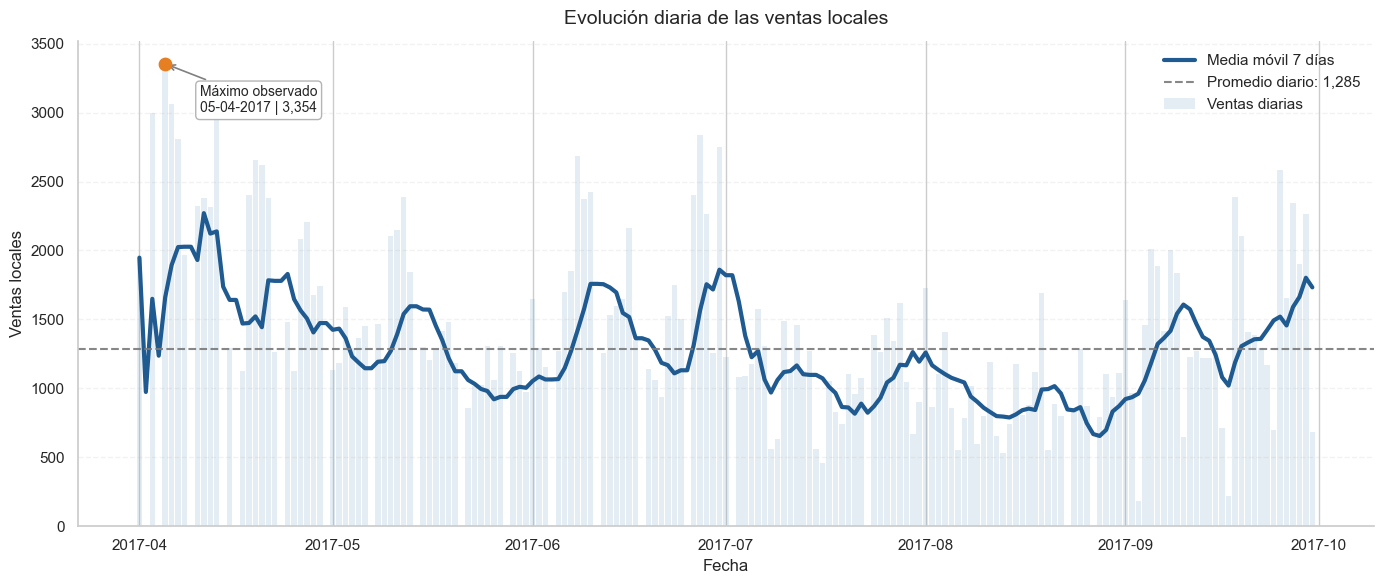

Resumen del bloque diario
- Rango analizado: 2017-04-01 a 2017-09-30
- Venta total acumulada: 235,168
- Venta promedio diaria: 1,285.1
- Mejor día observado: 2017-04-05 con 3,354


In [173]:
plot_daily = daily_totals.copy().sort_values("fecha").copy()

plot_daily["media_movil_7d"] = (
    plot_daily["local_total"]
    .rolling(window=7, min_periods=1)
    .mean()
)

max_row = plot_daily.loc[plot_daily["local_total"].idxmax()]
promedio_diario = plot_daily["local_total"].mean()

fig, ax = plt.subplots(figsize=(14, 6))

# Barras diarias
ax.bar(
    plot_daily["fecha"],
    plot_daily["local_total"],
    width=0.85,
    alpha=0.20,
    color="#7FA8C9",
    edgecolor="none",
    label="Ventas diarias"
)

# Línea de media móvil
ax.plot(
    plot_daily["fecha"],
    plot_daily["media_movil_7d"],
    color="#1F5A91",
    linewidth=3,
    label="Media móvil 7 días"
)

# Línea horizontal de promedio
ax.axhline(
    promedio_diario,
    linestyle="--",
    linewidth=1.5,
    color="#7A7A7A",
    alpha=0.9,
    label=f"Promedio diario: {promedio_diario:,.0f}"
)

# Marcar máximo
ax.scatter(
    max_row["fecha"],
    max_row["local_total"],
    color="#E67E22",
    s=80,
    zorder=5
)

ax.annotate(
    f"Máximo observado\n{max_row['fecha'].strftime('%d-%m-%Y')} | {max_row['local_total']:,.0f}",
    xy=(max_row["fecha"], max_row["local_total"]),
    xytext=(25, -35),
    textcoords="offset points",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#B0B0B0", alpha=0.95),
    arrowprops=dict(arrowstyle="->", color="#808080", lw=1.2)
)

# Formato de fechas
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=0)

# Estilo general
ax.set_title("Evolución diaria de las ventas locales", fontsize=14, pad=12)
ax.set_xlabel("Fecha")
ax.set_ylabel("Ventas locales")

ax.grid(axis="y", linestyle="--", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(frameon=False, loc="upper right")

plt.tight_layout()
plt.show()

# Resumen textual
print("Resumen del bloque diario")
print(f"- Rango analizado: {plot_daily['fecha'].min().date()} a {plot_daily['fecha'].max().date()}")
print(f"- Venta total acumulada: {plot_daily['local_total'].sum():,.0f}")
print(f"- Venta promedio diaria: {promedio_diario:,.1f}")
print(f"- Mejor día observado: {max_row['fecha'].date()} con {max_row['local_total']:,.0f}")



*   La serie diaria muestra que las ventas locales presentan una variabilidad considerable entre fechas, lo cual es esperable en un negocio minorista ubicado en un entorno universitario. Sin embargo, más allá de esa fluctuación diaria, la media móvil de siete días permite observar una trayectoria más estable y revela que el negocio atraviesa fases diferenciadas de mayor y menor intensidad comercial a lo largo del período analizado.

*   En particular, se observan niveles relativamente altos al inicio del horizonte de estudio, seguidos por una desaceleración progresiva en varios tramos intermedios y una recuperación más clara hacia septiembre. Este comportamiento sugiere que la demanda no responde únicamente a episodios aislados, sino que cambia de nivel en distintos momentos del semestre.

*   Desde una perspectiva de negocio, esta gráfica permite concluir que existe una dinámica temporal relevante en las ventas del segmento local. En consecuencia, resulta razonable profundizar en variables como el período académico, la composición de la demanda y el perfil del sabor, con el fin de evaluar si parte de estas variaciones puede explicarse por el contexto del caso y no solo por ruido operativo diario.

### **13.2. Composición mensual del segmento local: Student vs Staff:**

Después de examinar la evolución general de las ventas locales, resulta necesario analizar cómo se compone ese segmento entre los dos grupos que lo conforman: estudiantes y staff. Esta desagregación es importante porque permite identificar cuál de los dos grupos sostiene con mayor fuerza la demanda del punto de venta y si dicha composición permanece estable o cambia a lo largo del período analizado.

Para facilitar la lectura, la composición se examina a nivel mensual. El panel superior presenta el volumen total de ventas locales por mes, desagregado entre Student y Staff, mientras que el panel inferior muestra la participación porcentual de cada grupo dentro del total local. De esta manera, la visualización permite combinar una lectura de magnitud absoluta con una lectura de peso relativo.

Este análisis es especialmente relevante para el caso de Happy Cow, ya que la tienda se encuentra en un entorno universitario. Si el componente estudiantil domina de forma consistente, entonces la dinámica comercial del punto de venta estaría más estrechamente ligada al comportamiento del campus, lo cual refuerza la pertinencia de variables como el período académico en el análisis posterior.

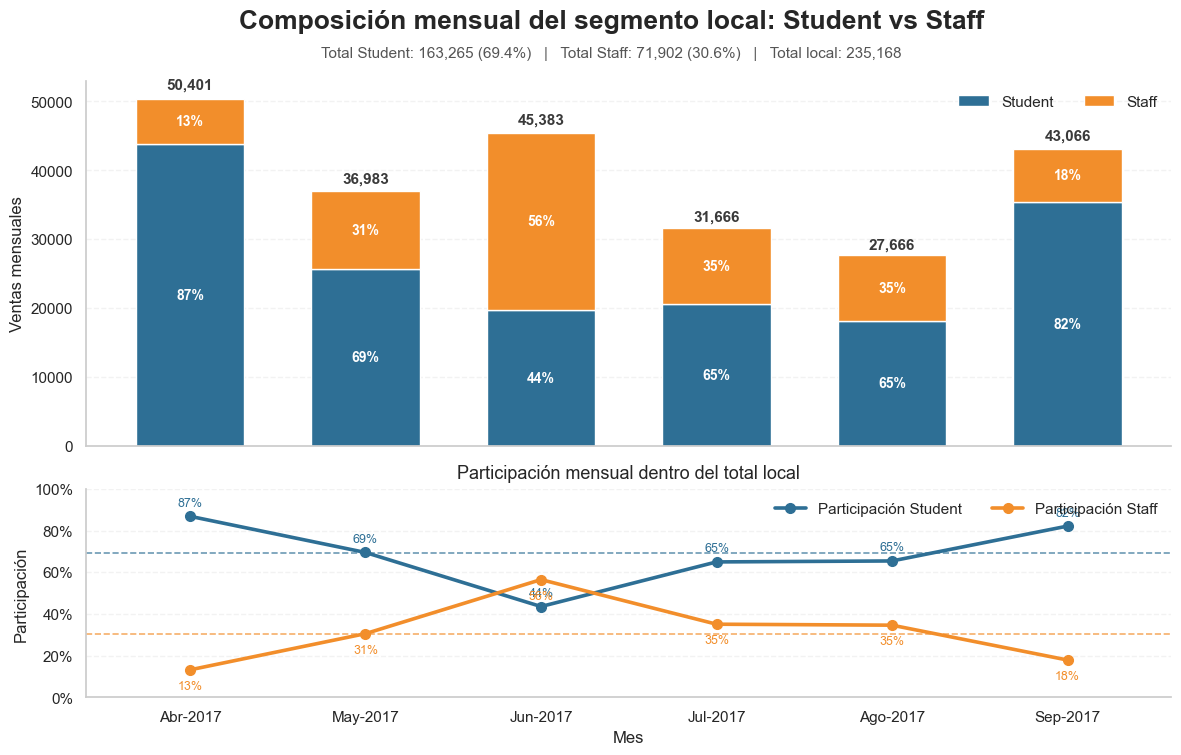

In [174]:
# ==========================================================
# 1. Preparación de datos
# ==========================================================
sns.set_theme(style="whitegrid")

plot_seg = daily_totals.copy().sort_values("fecha").copy()
plot_seg["mes"] = plot_seg["fecha"].dt.to_period("M").dt.to_timestamp()

monthly_seg = (
    plot_seg.groupby("mes", as_index=False)[["student_total", "staff_total", "local_total"]]
    .sum()
)

monthly_seg["student_share"] = monthly_seg["student_total"] / monthly_seg["local_total"]
monthly_seg["staff_share"] = monthly_seg["staff_total"] / monthly_seg["local_total"]

meses_es = {
    1: "Ene", 2: "Feb", 3: "Mar", 4: "Abr", 5: "May", 6: "Jun",
    7: "Jul", 8: "Ago", 9: "Sep", 10: "Oct", 11: "Nov", 12: "Dic"
}
monthly_seg["mes_label"] = monthly_seg["mes"].apply(
    lambda x: f"{meses_es[x.month]}-{x.year}"
)

student_total = monthly_seg["student_total"].sum()
staff_total = monthly_seg["staff_total"].sum()
local_total = monthly_seg["local_total"].sum()

student_share_total = student_total / local_total
staff_share_total = staff_total / local_total

# ==========================================================
# 2. Parámetros visuales
# ==========================================================
color_student = "#2E6F95"
color_staff = "#F28E2B"
color_text = "#3A3A3A"

x = np.arange(len(monthly_seg))

fig, axes = plt.subplots(
    2, 1,
    figsize=(14, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [2.1, 1.2]}
)

fig.patch.set_facecolor("white")

# ==========================================================
# 3. Título y subtítulo bien ubicados
# ==========================================================
fig.suptitle(
    "Composición mensual del segmento local: Student vs Staff",
    fontsize=19,
    fontweight="bold",
    y=0.97
)

fig.text(
    0.5, 0.91, # Adjusted y-position for more spacing
    f"Total Student: {student_total:,.0f} ({student_share_total:.1%})   |   "
    f"Total Staff: {staff_total:,.0f} ({staff_share_total:.1%})   |   "
    f"Total local: {local_total:,.0f}",
    ha="center",
    fontsize=11,
    color="#555555"
)

# ==========================================================
# 4. Panel superior: volumen mensual
# ==========================================================
ax1 = axes[0]

ax1.bar(
    x,
    monthly_seg["student_total"],
    width=0.62,
    color=color_student,
    label="Student"
)

ax1.bar(
    x,
    monthly_seg["staff_total"],
    width=0.62,
    bottom=monthly_seg["student_total"],
    color=color_staff,
    label="Staff"
)

# Totales arriba de cada barra
for i, total in enumerate(monthly_seg["local_total"]):
    ax1.text(
        x[i], total + total * 0.02,
        f"{int(total):,}",
        ha="center", va="bottom",
        fontsize=11, fontweight="bold", color=color_text
    )

# Etiquetas de porcentaje dentro de cada bloque
for i in range(len(monthly_seg)):
    st = monthly_seg.loc[i, "student_total"]
    sf = monthly_seg.loc[i, "staff_total"]
    st_share = monthly_seg.loc[i, "student_share"]
    sf_share = monthly_seg.loc[i, "staff_share"]

    if st > 250:
        ax1.text(
            x[i], st / 2,
            f"{st_share:.0%}",
            ha="center", va="center",
            fontsize=10, color="white", fontweight="bold"
        )
    if sf > 250:
        ax1.text(
            x[i], st + sf / 2,
            f"{sf_share:.0%}",
            ha="center", va="center",
            fontsize=10, color="white", fontweight="bold"
        )

ax1.set_ylabel("Ventas mensuales", fontsize=12)
ax1.legend(frameon=False, ncol=2, loc="upper right")

ax1.grid(axis="y", linestyle="--", alpha=0.25)
ax1.grid(axis="x", visible=False)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

# ==========================================================
# 5. Panel inferior: participación mensual
# ==========================================================
ax2 = axes[1]

ax2.plot(
    x, monthly_seg["student_share"],
    marker="o", markersize=7,
    linewidth=2.6, color=color_student,
    label="Participación Student"
)

ax2.plot(
    x, monthly_seg["staff_share"],
    marker="o", markersize=7,
    linewidth=2.6, color=color_staff,
    label="Participación Staff"
)

# Líneas promedio
ax2.axhline(student_share_total, linestyle="--", linewidth=1.2, color=color_student, alpha=0.7)
ax2.axhline(staff_share_total, linestyle="--", linewidth=1.2, color=color_staff, alpha=0.7)

# Etiquetas sobre los puntos
for i in range(len(monthly_seg)):
    ax2.text(
        x[i], monthly_seg.loc[i, "student_share"] + 0.035,
        f"{monthly_seg.loc[i, 'student_share']:.0%}",
        ha="center", va="bottom",
        fontsize=9, color=color_student
    )
    ax2.text(
        x[i], monthly_seg.loc[i, "staff_share"] - 0.05,
        f"{monthly_seg.loc[i, 'staff_share']:.0%}",
        ha="center", va="top",
        fontsize=9, color=color_staff
    )

ax2.set_title("Participación mensual dentro del total local", fontsize=13, pad=8)
ax2.set_ylabel("Participación", fontsize=12)
ax2.set_xlabel("Mes", fontsize=12)
ax2.set_ylim(0, 1)
ax2.yaxis.set_major_formatter(PercentFormatter(1.0))
ax2.set_xticks(x)
ax2.set_xticklabels(monthly_seg["mes_label"], fontsize=11)

ax2.grid(axis="y", linestyle="--", alpha=0.25)
ax2.grid(axis="x", visible=False)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.legend(frameon=False, ncol=2, loc="upper right")

# ==========================================================
# 6. Ajuste final de espacios
# ==========================================================
fig.subplots_adjust(top=0.88, hspace=0.15)

plt.show()


*   La composición mensual del segmento local muestra que el grupo de estudiantes concentra la mayor parte de las ventas durante casi todo el período analizado. En términos agregados, Student representa alrededor del 69.4% del total local, mientras que Staff aporta el 30.6%, lo que indica que la demanda del punto de venta está sostenida principalmente por el componente estudiantil.

*   No obstante, la participación relativa no es completamente constante a lo largo del tiempo. En algunos meses, como junio, el peso de Staff aumenta de forma considerable y llega a superar el 50% del total local, mientras que en abril y septiembre la dominancia de Student es mucho más marcada. Esto sugiere que la composición del segmento local no es rígida, sino que puede variar según el momento del período analizado.

*   Desde una perspectiva de negocio, esta gráfica refuerza la idea de que la tienda de HKU opera fundamentalmente sobre una base de demanda estudiantil, pero también muestra que el staff puede adquirir un papel más relevante en ciertos momentos. En consecuencia, el comportamiento de las ventas locales no debería interpretarse como homogéneo, sino como el resultado de una composición cambiante entre ambos grupos, lo que justifica incorporar más adelante variables temporales y académicas para entender mejor esas variaciones.

### **13.3. Ventas locales totales por mes:**

Una vez descrita la composición del segmento local, resulta útil examinar cómo varía el volumen total de ventas a lo largo de los meses observados. Esta agregación mensual permite reducir la volatilidad propia de la serie diaria y facilita la identificación de períodos relativamente más fuertes o más débiles en términos comerciales.

La siguiente visualización resume las ventas locales totales en cada mes del horizonte de estudio. A diferencia de un conteo de observaciones, esta gráfica refleja actividad comercial real y permite comparar la intensidad relativa de la demanda entre distintos momentos del semestre.

Desde la perspectiva del caso de negocio, esta lectura ayuda a identificar si existen meses con mayor presión operativa o con menor dinamismo de ventas, lo cual resulta relevante para pensar posteriormente en decisiones de surtido, rotación de sabores y planeación comercial.

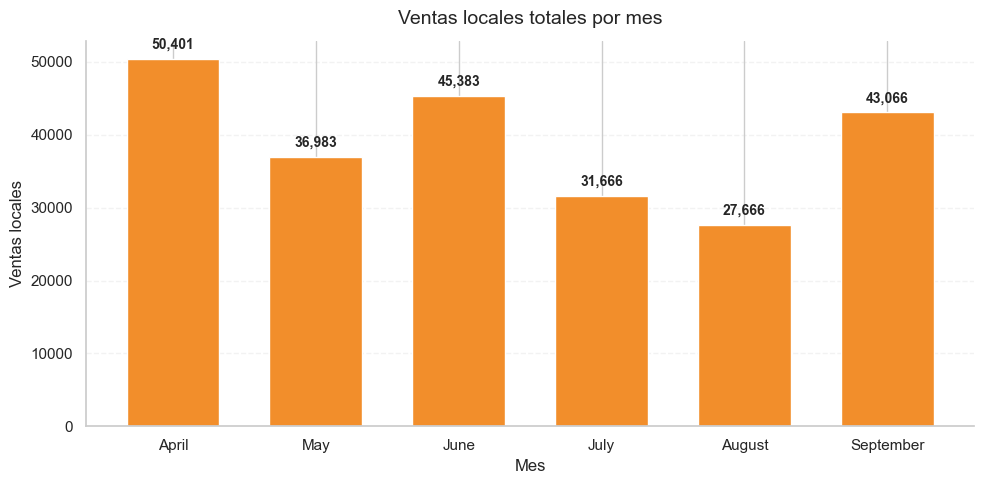

   mes_num        mes  ventas_local
0        4      April   50401.98384
1        5        May   36983.99994
2        6       June   45383.99990
3        7       July   31666.00000
4        8     August   27666.00000
5        9  September   43066.00004


In [175]:
sns.set_theme(style="whitegrid")

# ==========================================================
# 1. Funciones auxiliares
# ==========================================================
def first_existing(cols, candidates):
    for c in candidates:
        if c in cols:
            return c
    return None

# ==========================================================
# 2. Preparar fuente de datos mensual de forma robusta
# ==========================================================
# Caso A: si existe daily_totals, úsalo porque ya viene agregado por día
if "daily_totals" in globals():
    temp = daily_totals.copy()

    fecha_col = first_existing(
        temp.columns,
        ["fecha", "Fecha", "date", "Date", "DATE"]
    )
    local_col = first_existing(
        temp.columns,
        ["local_total", "ventas_local", "ventas", "sales", "TOTAL_LOCAL"]
    )

    if fecha_col is None or local_col is None:
        raise ValueError(
            f"No pude identificar columnas en daily_totals. Columnas disponibles: {list(temp.columns)}"
        )

    temp = temp[[fecha_col, local_col]].copy()
    temp.columns = ["fecha", "ventas_local"]

# Caso B: si no existe daily_totals, construirlo desde df_model
else:
    temp = df_model.copy()

    fecha_col = first_existing(
        temp.columns,
        ["fecha", "Fecha", "date", "Date", "DATE"]
    )

    if fecha_col is None:
        raise ValueError(
            f"No pude identificar la columna de fecha en df_model. Columnas disponibles: {list(temp.columns)}"
        )

    # 1) intentar columna local directa
    local_col = first_existing(
        temp.columns,
        ["ventas_local", "ventas", "sales", "local_total", "TOTAL_LOCAL"]
    )

    if local_col is not None:
        temp = temp[[fecha_col, local_col]].copy()
        temp.columns = ["fecha", "ventas_local"]

    else:
        # 2) intentar construir ventas_local con student + staff
        student_col = first_existing(
            temp.columns,
            ["ventas_student", "student_total", "student_sales", "Student", "student"]
        )
        staff_col = first_existing(
            temp.columns,
            ["ventas_staff", "staff_total", "staff_sales", "Staff", "staff"]
        )

        if student_col is not None and staff_col is not None:
            temp = temp[[fecha_col, student_col, staff_col]].copy()
            temp["ventas_local"] = temp[student_col] + temp[staff_col]
            temp = temp[[fecha_col, "ventas_local"]]
            temp.columns = ["fecha", "ventas_local"]

        else:
            raise ValueError(
                "No encontré una columna de ventas local ni columnas separadas de Student y Staff.\n"
                f"Columnas disponibles en df_model: {list(temp.columns)}"
            )

    # Si df_model está a nivel sabor-día, agregamos por fecha
    temp = (
        temp.groupby("fecha", as_index=False)["ventas_local"]
        .sum()
    )

# ==========================================================
# 3. Asegurar fecha y construir mes
# ==========================================================
temp["fecha"] = pd.to_datetime(temp["fecha"], errors="coerce")
temp = temp[temp["fecha"].notna()].copy()

temp["mes_num"] = temp["fecha"].dt.month
temp["mes"] = temp["fecha"].dt.month_name()

orden_meses = ["April", "May", "June", "July", "August", "September"]

ventas_mes = (
    temp.groupby(["mes_num", "mes"], as_index=False)["ventas_local"]
    .sum()
    .sort_values("mes_num")
)

ventas_mes["mes"] = pd.Categorical(
    ventas_mes["mes"],
    categories=orden_meses,
    ordered=True
)
ventas_mes = ventas_mes.sort_values("mes")

# ==========================================================
# 4. Gráfica bonita de ventas por mes
# ==========================================================
fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(
    ventas_mes["mes"],
    ventas_mes["ventas_local"],
    color="#F28E2B",
    width=0.65
)

for bar, value in zip(bars, ventas_mes["ventas_local"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + ventas_mes["ventas_local"].max() * 0.02,
        f"{int(value):,}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

ax.set_title("Ventas locales totales por mes", fontsize=14, pad=12)
ax.set_xlabel("Mes")
ax.set_ylabel("Ventas locales")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.25)

plt.tight_layout()
plt.show()

# ==========================================================
# 5. Tabla resumen
# ==========================================================
print(ventas_mes)



*   La agregación mensual muestra que el comportamiento de las ventas no fue homogéneo durante el período analizado. Abril registra el mayor volumen de ventas locales, seguido por junio y septiembre, mientras que julio y, especialmente, agosto presentan niveles más bajos de actividad comercial. Esto sugiere que la demanda del punto de venta experimenta cambios relevantes a lo largo del semestre y no se mantiene constante en el tiempo.

*   En términos descriptivos, la gráfica permite distinguir al menos tres momentos. En primer lugar, un inicio fuerte del período, representado por abril. En segundo lugar, una caída progresiva hacia julio y agosto, donde se observan los niveles más bajos de ventas. Finalmente, una recuperación importante en septiembre, que devuelve el volumen comercial a niveles comparativamente altos.

*   Desde una perspectiva de negocio, este patrón respalda la idea de que la dinámica de ventas está influida por factores temporales más amplios que la variación diaria. En consecuencia, resulta razonable profundizar en variables como el período académico, el contexto estacional y el perfil del sabor para evaluar si parte de estas diferencias mensuales puede explicarse por el entorno del caso y no solo por fluctuaciones operativas aisladas.

### **13.4. Distribución de ventas locales por día de la semana:**

Después de observar la evolución diaria y la agregación mensual de las ventas, resulta pertinente analizar si existe una rutina operativa semanal en la demanda del segmento local. Para ello, se examina la distribución de las ventas diarias según el día de la semana.

La visualización combina un boxplot con una línea de promedios. El boxplot permite observar la dispersión de las ventas, la posición de la mediana y la presencia de posibles valores atípicos para cada día, mientras que la línea de promedios facilita comparar el nivel medio de ventas entre categorías. En conjunto, esta representación permite identificar si algunos días concentran sistemáticamente una mayor intensidad comercial que otros.

Este análisis es útil porque, si existen diferencias claras entre días de la semana, parte de la variación observada en las ventas podría estar asociada a una rutina temporal recurrente y no únicamente a factores de corto plazo o a la preferencia por ciertos sabores.

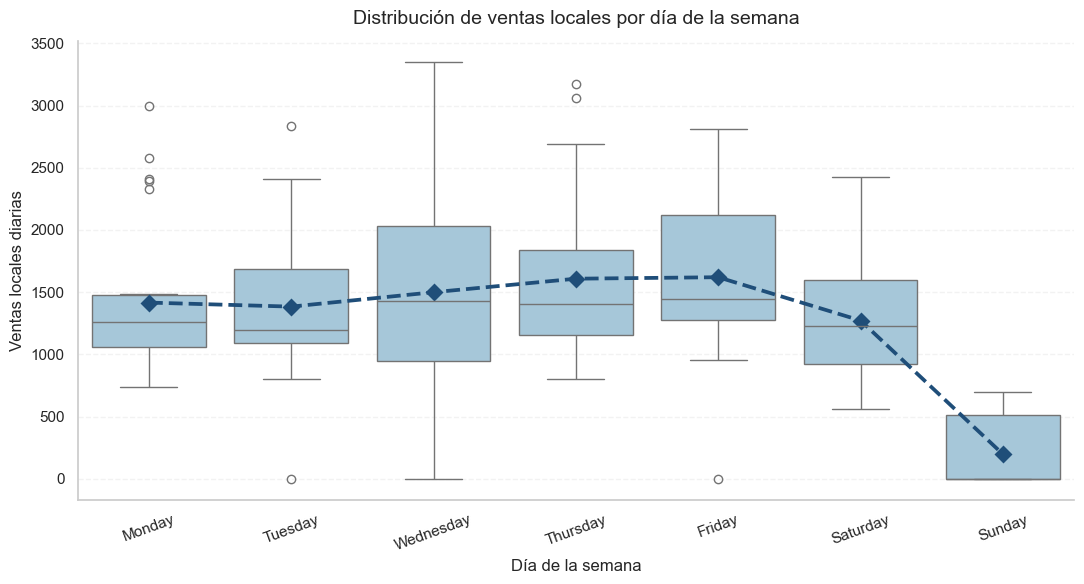

                 mean  median    min     max
dia_de_semana                               
Monday         1415.9  1256.0  738.0  3000.0
Tuesday        1383.5  1197.0    0.0  2838.0
Wednesday      1499.3  1432.0    0.0  3354.0
Thursday       1608.0  1401.0  800.0  3172.0
Friday         1619.9  1442.0    0.0  2808.0
Saturday       1271.7  1224.0  562.0  2424.0
Sunday          197.6     0.0    0.0   696.0


In [176]:
sns.set_theme(style="whitegrid")

orden_dias = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

# Agregar a nivel día
ventas_dia = (
    df_model.groupby(["fecha", "dia_de_semana"], as_index=False)["ventas"]
    .sum()
)

ventas_dia["dia_de_semana"] = pd.Categorical(
    ventas_dia["dia_de_semana"],
    categories=orden_dias,
    ordered=True
)

fig, ax = plt.subplots(figsize=(11, 6))

sns.boxplot(
    data=ventas_dia,
    x="dia_de_semana",
    y="ventas",
    order=orden_dias,
    color="#9ecae1",
    ax=ax
)

sns.pointplot(
    data=ventas_dia,
    x="dia_de_semana",
    y="ventas",
    order=orden_dias,
    estimator=np.mean,
    errorbar=None,
    color="#1f4e79",
    markers="D",
    linestyles="--",
    ax=ax
)

ax.set_title("Distribución de ventas locales por día de la semana", fontsize=14, pad=12)
ax.set_xlabel("Día de la semana")
ax.set_ylabel("Ventas locales diarias")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.25)

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# Resumen numérico
resumen_semana = (
    ventas_dia.groupby("dia_de_semana")["ventas"]
    .agg(["mean", "median", "min", "max"])
    .reindex(orden_dias)
    .round(1)
)

print(resumen_semana)



*   La distribución de ventas por día de la semana muestra que el comportamiento comercial del punto de venta no es completamente homogéneo a lo largo de la semana. En términos generales, jueves y viernes presentan los promedios más altos de ventas, seguidos por miércoles, mientras que lunes, martes y sábado se ubican en niveles intermedios. En contraste, domingo muestra un patrón marcadamente inferior, con una media mucho más baja y una mediana cercana a cero.

*   Además de las diferencias en nivel promedio, la gráfica evidencia que algunos días presentan una dispersión considerable, especialmente miércoles, jueves y viernes. Esto sugiere que, además de registrar mayores niveles de ventas, esos días también concentran mayor variabilidad operativa. En otras palabras, parecen ser jornadas con más potencial comercial, pero también más sensibles a fluctuaciones.

*   Desde una perspectiva de negocio, estos resultados sugieren la existencia de una rutina semanal en la demanda del segmento local. Esto implica que la intensidad comercial no depende únicamente del mes o de la temporada, sino también del día específico dentro de la semana. En consecuencia, esta variable temporal puede aportar información útil en etapas posteriores del análisis y del modelado.

### **13.5. Distribución de la variable de ventas:**

Una vez examinados los patrones temporales del negocio, conviene analizar la distribución de la variable `ventas`, ya que esta constituye la medida base sobre la cual se construyó el desempeño relativo de cada sabor. Esta revisión permite entender si las ventas observadas se concentran en un rango estrecho o si, por el contrario, presentan alta dispersión, asimetría y valores extremos.

La visualización combina dos perspectivas complementarias. En primer lugar, se presenta un histograma con curva de densidad, que permite observar la forma general de la distribución y detectar posibles concentraciones en valores bajos o colas largas hacia valores altos. En segundo lugar, se incluye un boxplot horizontal, útil para resumir la posición central, el rango intercuartílico y la presencia de observaciones atípicas.

Esta lectura es importante porque ayuda a caracterizar la naturaleza estadística de la variable de ventas y permite anticipar si el comportamiento del negocio está dominado por muchas observaciones de baja magnitud y unas pocas de valor considerablemente más alto.

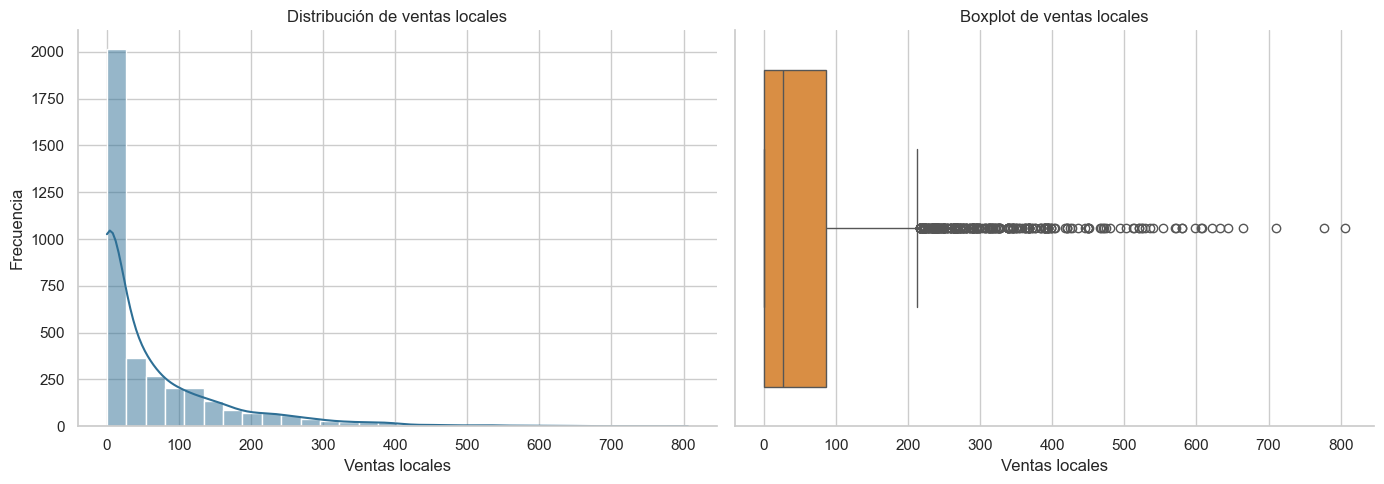

Resumen descriptivo de ventas_local
count    3660.00
mean       64.25
std        98.43
min         0.00
25%         0.00
50%        26.00
75%        86.00
max       806.00
Name: ventas, dtype: float64

Asimetría:
2.415


In [177]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma + KDE
sns.histplot(
    data=df_model,
    x="ventas",
    bins=30,
    kde=True,
    ax=axes[0],
    color="#2E6F95"
)
axes[0].set_title("Distribución de ventas locales")
axes[0].set_xlabel("Ventas locales")
axes[0].set_ylabel("Frecuencia")
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

# Boxplot
sns.boxplot(
    data=df_model,
    x="ventas",
    ax=axes[1],
    color="#F28E2B"
)
axes[1].set_title("Boxplot de ventas locales")
axes[1].set_xlabel("Ventas locales")
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

print("Resumen descriptivo de ventas_local")
print(df_model["ventas"].describe().round(2))

print("\nAsimetría:")
print(round(df_model["ventas"].skew(), 3))


*   La distribución de la variable `ventas` presenta una asimetría positiva marcada. La mayor parte de las observaciones se concentra en valores bajos, mientras que existe una cola extensa hacia la derecha, lo que indica la presencia de registros con ventas considerablemente más altas que el comportamiento típico. Esta forma sugiere que la dinámica de ventas no es uniforme y que una parte importante del volumen total puede estar influida por un conjunto relativamente reducido de observaciones de alta magnitud.

*   El boxplot confirma esta lectura al mostrar una mediana baja, un rango intercuartílico relativamente concentrado y una cantidad importante de valores atípicos hacia la parte superior de la distribución. En términos prácticos, esto indica que el comportamiento usual de las ventas por sabor y por día se ubica en niveles modestos, mientras que los valores más altos corresponden a situaciones menos frecuentes pero comercialmente relevantes.

*   Desde una perspectiva analítica, esta estructura de la variable resulta coherente con un contexto minorista donde muchos registros presentan ventas bajas o incluso nulas, y solo algunos sabores o días alcanzan niveles excepcionalmente altos. Por ello, la variable de ventas no debe interpretarse como simétrica ni estable, sino como una variable altamente concentrada y con presencia clara de extremos, lo que será importante al momento de interpretar patrones posteriores y resultados de modelado.

### **13.6. Distribución de la variable objetivo `top_seller`:**

Antes de avanzar hacia el modelado, conviene revisar la distribución de la variable objetivo `top_seller`, ya que esta define el problema de clasificación que se abordará en las siguientes etapas. En este caso, la variable fue construida de manera operativa a partir del desempeño relativo diario de los sabores: para cada fecha, se clasificaron como `top_seller = 1` los sabores ubicados en el grupo de mejor rendimiento y como `top_seller = 0` los restantes.

La siguiente visualización permite verificar la proporción de cada clase en la base final. Esta revisión es importante porque ayuda a entender la estructura del problema supervisado, anticipar el comportamiento de métricas de clasificación y documentar si existe o no desbalance entre clases.

A diferencia de otras gráficas del EDA, esta lectura tiene un propósito principalmente metodológico: no busca describir directamente la dinámica del negocio, sino validar la forma en que se definió el target del modelo.

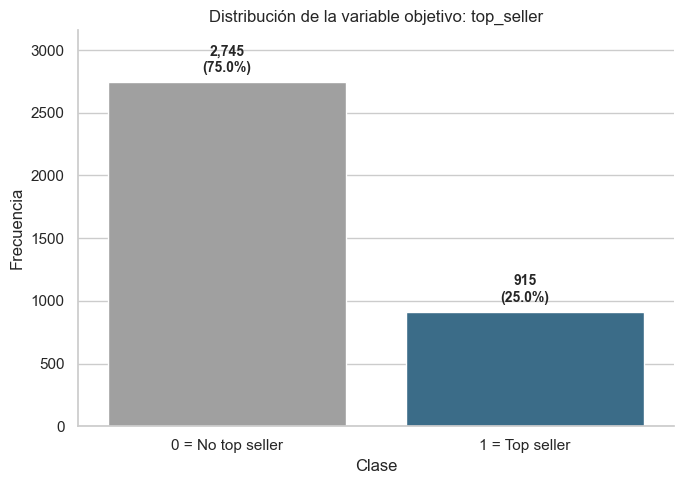

Conteos de top_seller
top_seller
0    2745
1     915
Name: count, dtype: int64

Proporciones de top_seller
top_seller
0    0.75
1    0.25
Name: proportion, dtype: float64


In [178]:
top_counts = df_model["top_seller"].value_counts().sort_index()
top_props = df_model["top_seller"].value_counts(normalize=True).sort_index()

fig, ax = plt.subplots(figsize=(7, 5))

sns.countplot(
    data=df_model,
    x="top_seller",
    ax=ax,
    palette=["#A0A0A0", "#2E6F95"]
)

ax.set_title("Distribución de la variable objetivo: top_seller")
ax.set_xlabel("Clase")
ax.set_ylabel("Frecuencia")
ax.set_xticklabels(["0 = No top seller", "1 = Top seller"])

for i, v in enumerate(top_counts.values):
    ax.text(i, v + max(top_counts.values)*0.02, f"{v:,}\n({top_props.iloc[i]:.1%})",
            ha="center", va="bottom", fontsize=10, fontweight="bold")

# Adjust y-axis limit to create more space for annotations and prevent overlap with title
ax.set_ylim(0, max(top_counts.values) * 1.15)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

print("Conteos de top_seller")
print(top_counts)
print("\nProporciones de top_seller")
print(top_props.round(3))



*   La variable `top_seller` presenta una distribución de 75% para la clase negativa y 25% para la clase positiva. Sin embargo, esta proporción no debe interpretarse como un hallazgo espontáneo del negocio, sino como una consecuencia directa de la regla utilizada para construir el target. En particular, la clase positiva corresponde al subconjunto de sabores que, en cada día, fueron clasificados como parte del grupo de mejor desempeño relativo.

*   Por tanto, esta gráfica no describe una preferencia natural del mercado en sentido estricto, sino la estructura metodológica del problema de clasificación que se utilizará en el modelado. Su valor principal radica en dejar explícito que el dataset resultante presenta una distribución controlada de clases, lo cual deberá tenerse en cuenta al interpretar posteriormente métricas como accuracy, precisión, recall y F1-score.

*   En términos prácticos, esta revisión confirma que la variable objetivo fue construida de manera consistente y que la clase positiva representa una fracción minoritaria pero no extrema del total de observaciones, lo que hace viable continuar con modelos supervisados sin enfrentar un desbalance severo.

### **13.7. Frecuencia de observaciones por período académico:**

Como parte de la caracterización de la base analítica, resulta útil revisar cómo se distribuyen las observaciones entre los distintos períodos académicos definidos para el caso. Esta variable es especialmente relevante porque la tienda se encuentra en un entorno universitario y, por tanto, el calendario académico puede influir en la dinámica de la demanda local.

La siguiente visualización muestra el número de registros asociados a cada categoría de `periodo_academico`. Su propósito principal es describir la cobertura temporal de la base y verificar qué momentos del semestre tienen mayor presencia dentro del conjunto de datos analizado.

Más que un hallazgo comercial en sí mismo, esta gráfica permite contextualizar los resultados posteriores, ya que una representación desigual entre períodos puede afectar la interpretación de patrones observados en las ventas.

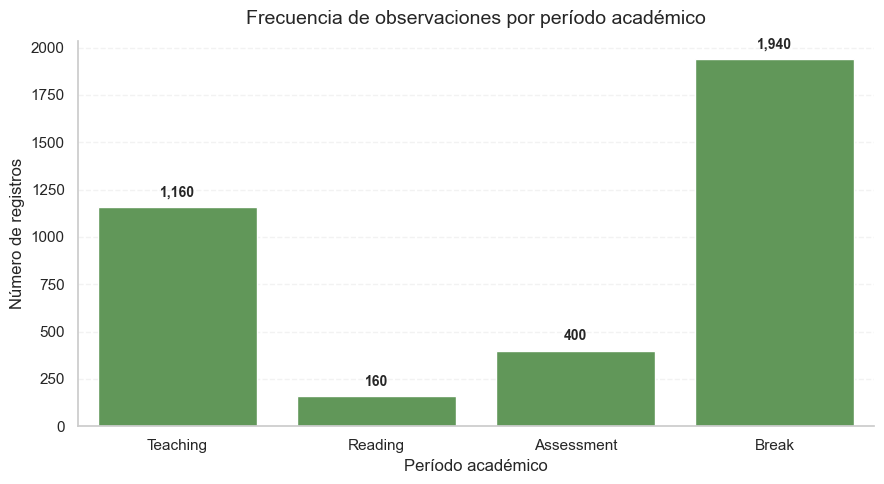

In [179]:
orden_periodos = ["Teaching", "Reading", "Assessment", "Break"]

plot_period = df_model.copy()
plot_period["periodo_academico"] = pd.Categorical(
    plot_period["periodo_academico"],
    categories=orden_periodos,
    ordered=True
)

period_counts = (
    plot_period["periodo_academico"]
    .value_counts()
    .reindex(orden_periodos)
)

fig, ax = plt.subplots(figsize=(9, 5))

sns.countplot(
    data=plot_period,
    x="periodo_academico",
    order=orden_periodos,
    color="#59A14F",
    ax=ax
)

ax.set_title("Frecuencia de observaciones por período académico", fontsize=14, pad=12)
ax.set_xlabel("Período académico")
ax.set_ylabel("Número de registros")

for i, v in enumerate(period_counts.values):
    if pd.notna(v):
        ax.text(
            i, v + max(period_counts.values) * 0.02,
            f"{int(v):,}",
            ha="center", va="bottom",
            fontsize=10, fontweight="bold"
        )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.25)

plt.tight_layout()
plt.show()



*   La distribución de observaciones por período académico muestra una cobertura claramente desigual entre categorías. El período `Break` concentra la mayor cantidad de registros, seguido por `Teaching`, mientras que `Assessment` y, especialmente, `Reading`, tienen una representación mucho menor en la base analítica.

*   Este resultado no debe interpretarse directamente como evidencia de mayor actividad comercial en esos períodos, sino como una característica de la estructura temporal del dataset. En otras palabras, la gráfica indica que algunos momentos del calendario académico están más presentes que otros en la información disponible, lo cual es importante al analizar posteriormente la relación entre período académico y ventas.

*   Desde una perspectiva metodológica, esta revisión sugiere que los resultados asociados a categorías con menor número de observaciones deberán interpretarse con más cautela. Al mismo tiempo, confirma que el calendario académico constituye una dimensión relevante dentro de la base y justifica su inclusión como variable explicativa en el análisis posterior.

### **13.8. Frecuencia de observaciones por mal estacional:**

Como parte de la caracterización de la base analítica, también es importante revisar cómo se distribuyen las observaciones entre las categorías de `mal_estacional`. Esta variable recoge la clasificación estacional inspirada en la Medicina Tradicional China y constituye una de las dimensiones conceptuales más relevantes del proyecto, ya que conecta el contexto temporal con la hipótesis cultural del caso.

La siguiente visualización muestra el número de registros disponibles para cada categoría de mal estacional. Su objetivo principal es describir la cobertura de la base y verificar qué condiciones estacionales están efectivamente representadas dentro del período analizado.

Al igual que en el caso del período académico, esta gráfica no debe entenderse principalmente como un hallazgo comercial, sino como una revisión de la estructura del dataset. Esto permitirá interpretar con mayor cuidado los análisis posteriores relacionados con estacionalidad y perfil de sabores.

Conteo de valores por mal estacional:
mal_estacional
Summer_Heat    1840
Dampness       1220
Wind            600
Name: count, dtype: int64


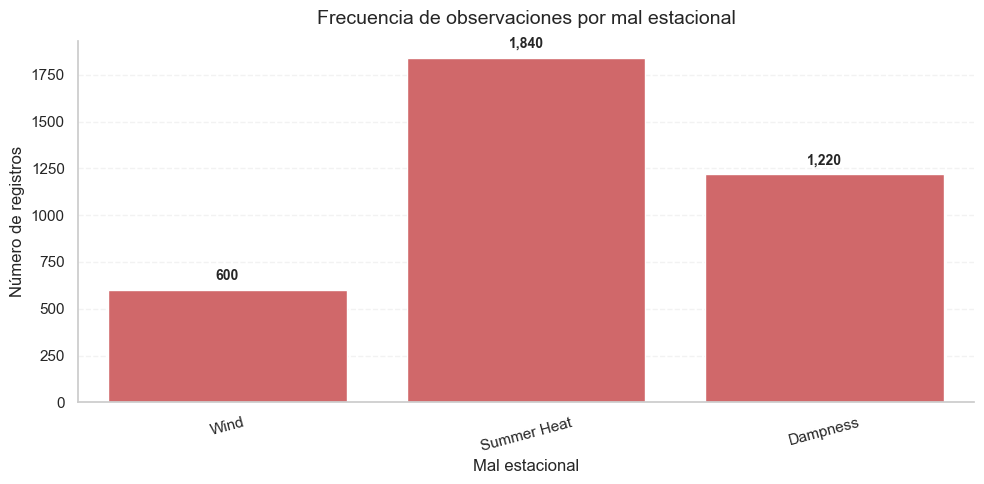

In [180]:
# Revisar valores reales de la variable
print("Conteo de valores por mal estacional:")
print(df_model["mal_estacional"].value_counts(dropna=False))


sns.set_theme(style="whitegrid")

# Copia de trabajo
plot_season = df_model.copy()

# Normalizar nombres para que no falle el gráfico
plot_season["mal_estacional"] = (
    plot_season["mal_estacional"]
    .replace({
        "Summer_Heat": "Summer Heat",
        "SummerHeat": "Summer Heat",
        "summer_heat": "Summer Heat"
    })
)

# Orden correcto
orden_males = ["Wind", "Summer Heat", "Dampness"]

# Conteos
season_counts = (
    plot_season["mal_estacional"]
    .value_counts()
    .reindex(orden_males, fill_value=0)
)

# Gráfico
fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(
    x=season_counts.index,
    y=season_counts.values,
    color="#E15759",
    ax=ax
)

ax.set_title("Frecuencia de observaciones por mal estacional", fontsize=14, pad=12)
ax.set_xlabel("Mal estacional")
ax.set_ylabel("Número de registros")

for i, v in enumerate(season_counts.values):
    if v > 0:
        ax.text(
            i,
            v + max(season_counts.values) * 0.02,
            f"{int(v):,}",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold"
        )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.25)

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()



*   La distribución de observaciones por `mal_estacional` muestra una cobertura desigual dentro de las categorías efectivamente presentes en la base. En particular, `Summer Heat` concentra la mayor cantidad de registros, con **1.840 observaciones**, seguido por `Dampness`, con **1.220**, mientras que `Wind` presenta una representación menor, con **600** registros.

*   Este resultado es coherente con la ventana temporal del dataset, que cubre de abril a septiembre de 2017. Por tanto, la base ofrece mayor soporte empírico para analizar condiciones asociadas al calor de verano y la humedad, y en menor medida para condiciones vinculadas al viento. En consecuencia, la lectura de patrones posteriores deberá entenderse principalmente dentro de ese marco estacional específico.

*   Desde una perspectiva metodológica, esta gráfica confirma que la dimensión estacional sí está presente en la base y que cuenta con suficiente variación para ser incorporada en el análisis posterior. Al mismo tiempo, también deja claro que la evidencia no está distribuida de manera uniforme entre categorías, por lo que cualquier comparación entre males estacionales debe interpretarse considerando esa diferencia de cobertura.

### **13.9. Relación entre el perfil del sabor y la variable objetivo `top_seller`:**

Después de analizar la frecuencia de las principales variables categóricas del perfil del sabor y su relación con el nivel de ventas, resulta pertinente examinar cómo estas mismas características se asocian con la variable objetivo `top_seller`. En esta etapa, el interés ya no se centra en cuánto vende cada categoría en promedio, sino en identificar qué perfiles aparecen con mayor frecuencia dentro del grupo de sabores de mejor desempeño relativo.

Para ello, la figura combina dos tipos de información para cada dimensión del perfil del sabor. En la columna izquierda se muestra la frecuencia de observaciones por categoría, lo que permite contextualizar el peso de cada grupo dentro de la base. En la columna derecha se presenta la proporción de observaciones clasificadas como `top_seller`, es decir, el porcentaje de veces que cada categoría logra ubicarse dentro del grupo de mejor rendimiento relativo.

Este análisis es importante porque permite pasar de una lectura puramente descriptiva del portafolio a una lectura más cercana al objetivo del modelo. En otras palabras, ayuda a evaluar si ciertas características del sabor no solo están presentes en la base, sino que además parecen asociarse con una mayor probabilidad de destacar frente a las demás.

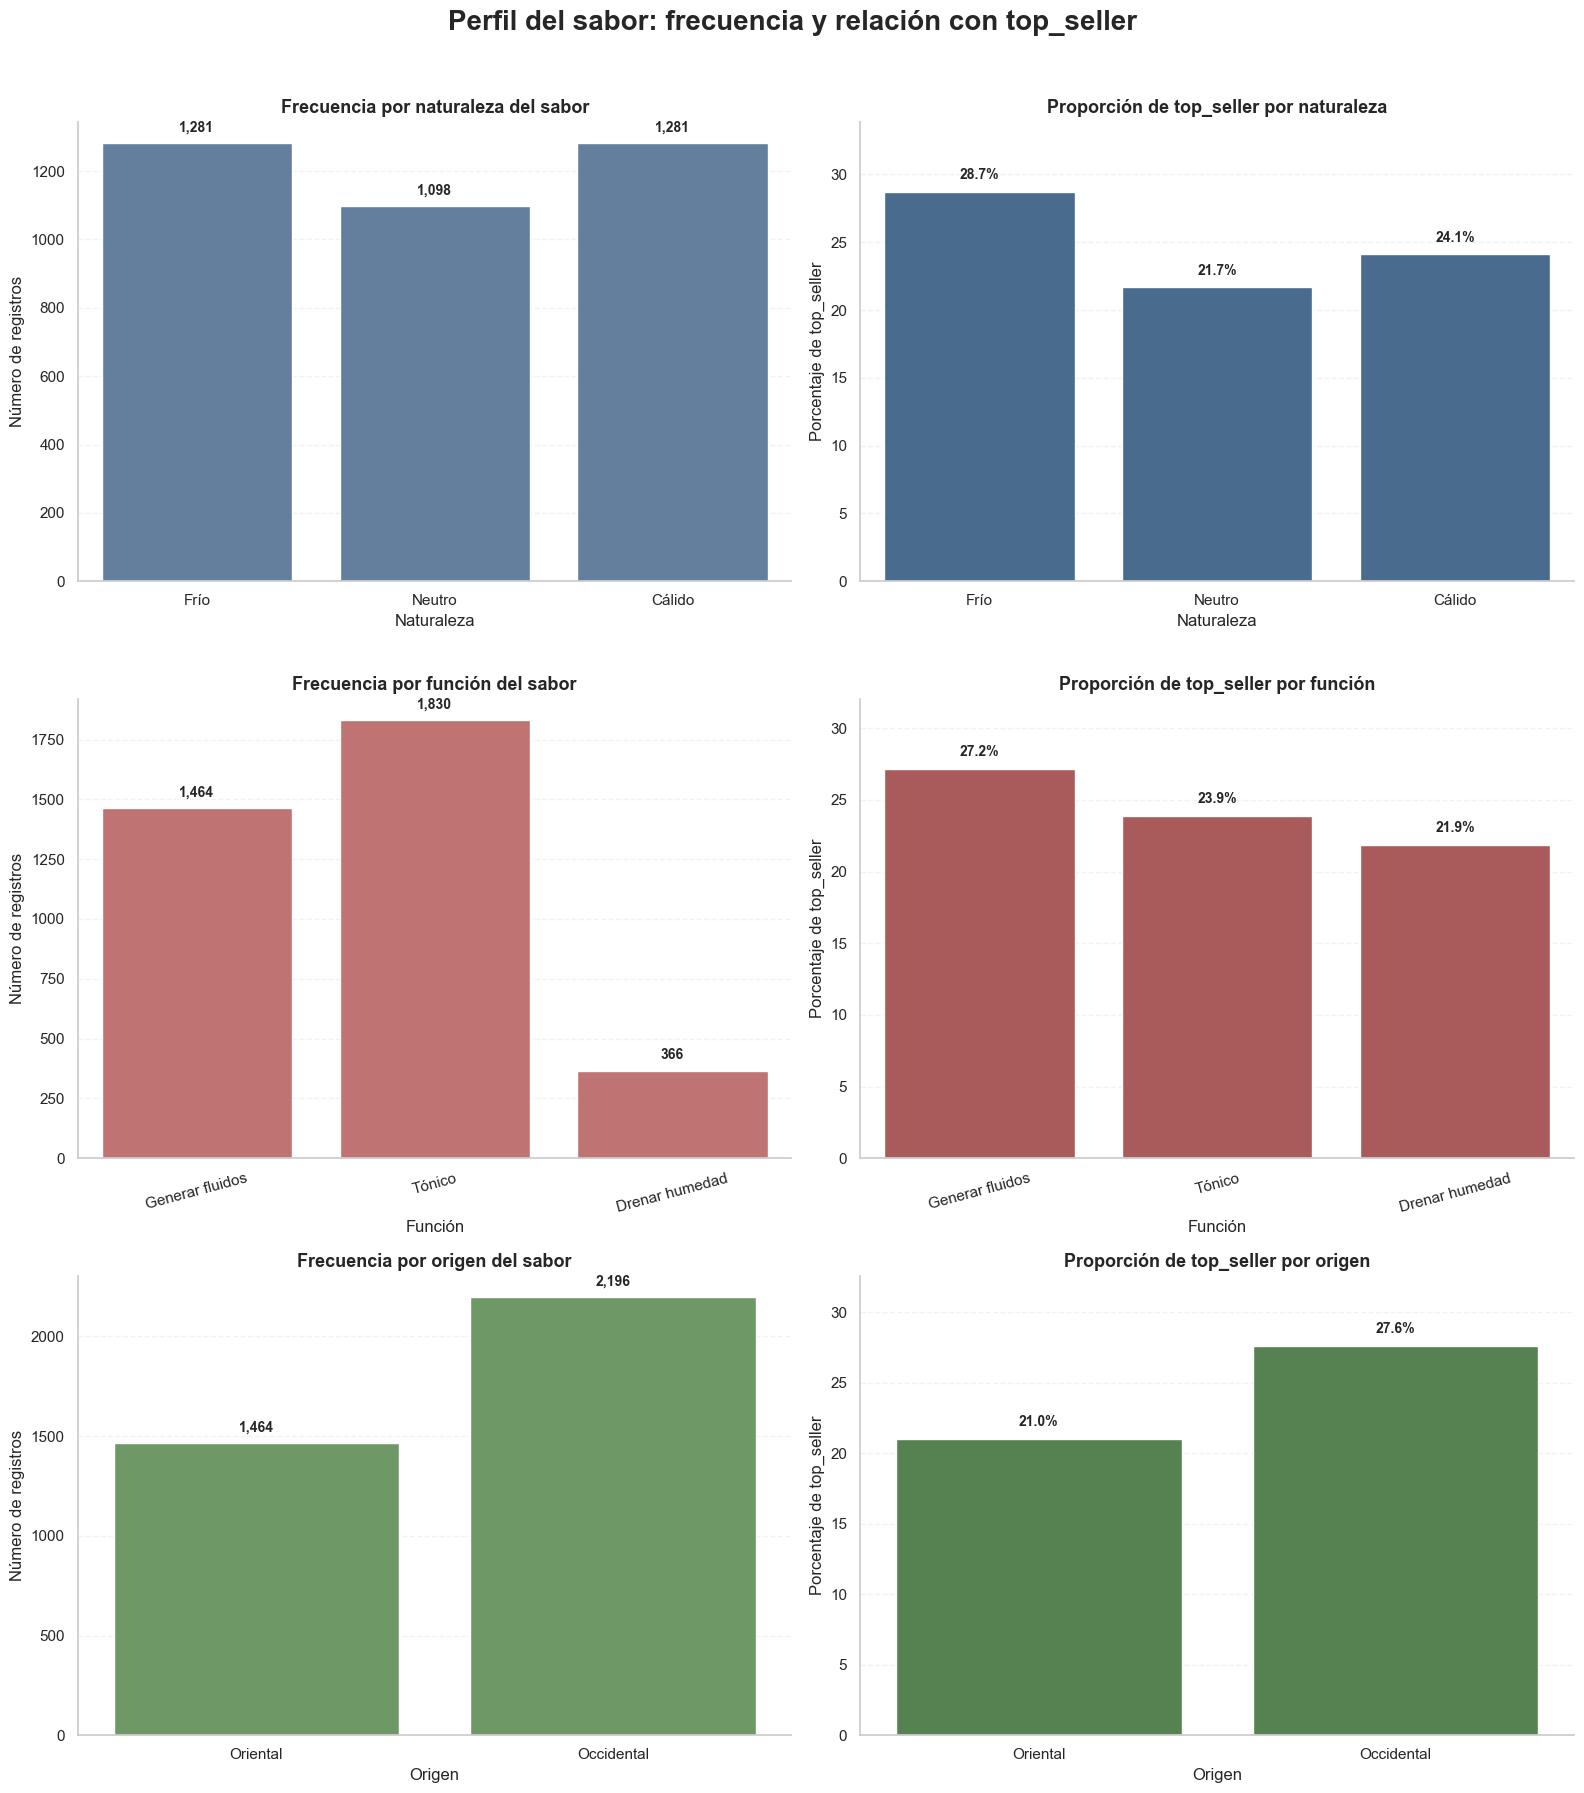


Frecuencia por naturaleza del sabor:
  categoria  frecuencia
0      Frío        1281
1    Neutro        1098
2    Cálido        1281

Proporción de top_seller por naturaleza del sabor:
  naturaleza_sabor  porcentaje
1             Frío   28.727557
2           Neutro   21.675774
0           Cálido   24.121780

Frecuencia por función del sabor:
         categoria  frecuencia
0  Generar fluidos        1464
1           Tónico        1830
2   Drenar humedad         366

Proporción de top_seller por función del sabor:
     funcion_sabor  porcentaje
1  Generar fluidos   27.185792
2           Tónico   23.879781
0   Drenar humedad   21.857923

Frecuencia por origen del sabor:
    categoria  frecuencia
0    Oriental        1464
1  Occidental        2196

Proporción de top_seller por origen del sabor:
  origen_sabor  porcentaje
1     Oriental   21.038251
0   Occidental   27.641166


In [181]:
# ==========================================================
# 1. Copia de trabajo y limpieza básica de etiquetas
# ==========================================================
sns.set_theme(style="whitegrid")

plot_df = df_model.copy()

# Limpiar texto
for col in ["naturaleza_sabor", "funcion_sabor", "origen_sabor"]:
    plot_df[col] = plot_df[col].astype(str).str.strip()

# Corregir etiquetas para que se vean bonitas
plot_df["naturaleza_sabor"] = plot_df["naturaleza_sabor"].replace({
    "Frio": "Frío",
    "Calido": "Cálido"
})

plot_df["funcion_sabor"] = plot_df["funcion_sabor"].replace({
    "Generar_fluidos": "Generar fluidos",
    "Tonico": "Tónico",
    "Drenar_humedad": "Drenar humedad"
})

# ==========================================================
# 2. Definir orden de categorías
# ==========================================================
orden_nat = ["Frío", "Neutro", "Cálido"]
orden_func = ["Generar fluidos", "Tónico", "Drenar humedad"]
orden_ori = ["Oriental", "Occidental"]

# ==========================================================
# 3. Preparar datos de frecuencia
# ==========================================================
freq_nat = (
    plot_df["naturaleza_sabor"]
    .value_counts()
    .reindex(orden_nat)
    .fillna(0)
    .reset_index()
)
freq_nat.columns = ["categoria", "frecuencia"]

freq_func = (
    plot_df["funcion_sabor"]
    .value_counts()
    .reindex(orden_func)
    .fillna(0)
    .reset_index()
)
freq_func.columns = ["categoria", "frecuencia"]

freq_ori = (
    plot_df["origen_sabor"]
    .value_counts()
    .reindex(orden_ori)
    .fillna(0)
    .reset_index()
)
freq_ori.columns = ["categoria", "frecuencia"]

# ==========================================================
# 4. Preparar datos de proporción de top_seller
# ==========================================================
prop_nat = (
    plot_df.groupby("naturaleza_sabor", as_index=False)["top_seller"]
    .mean()
)
prop_nat["naturaleza_sabor"] = pd.Categorical(
    prop_nat["naturaleza_sabor"], categories=orden_nat, ordered=True
)
prop_nat = prop_nat.sort_values("naturaleza_sabor")
prop_nat["porcentaje"] = prop_nat["top_seller"] * 100

prop_func = (
    plot_df.groupby("funcion_sabor", as_index=False)["top_seller"]
    .mean()
)
prop_func["funcion_sabor"] = pd.Categorical(
    prop_func["funcion_sabor"], categories=orden_func, ordered=True
)
prop_func = prop_func.sort_values("funcion_sabor")
prop_func["porcentaje"] = prop_func["top_seller"] * 100

prop_ori = (
    plot_df.groupby("origen_sabor", as_index=False)["top_seller"]
    .mean()
)
prop_ori["origen_sabor"] = pd.Categorical(
    prop_ori["origen_sabor"], categories=orden_ori, ordered=True
)
prop_ori = prop_ori.sort_values("origen_sabor")
prop_ori["porcentaje"] = prop_ori["top_seller"] * 100

# ==========================================================
# 5. Crear panel combinado 3x2
# ==========================================================
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle(
    "Perfil del sabor: frecuencia y relación con top_seller",
    fontsize=20,
    fontweight="bold",
    y=0.995
)

# Colores
color_freq_nat = "#5B7FA6"
color_freq_func = "#CC6666"
color_freq_ori = "#6AA05F"

color_prop_nat = "#3E6B99"
color_prop_func = "#B64E4E"
color_prop_ori = "#4F8A48"

# ----------------------------------------------------------
# Fila 1: Naturaleza
# ----------------------------------------------------------
ax = axes[0, 0]
sns.barplot(data=freq_nat, x="categoria", y="frecuencia", color=color_freq_nat, ax=ax)
ax.set_title("Frecuencia por naturaleza del sabor", fontsize=13, fontweight="bold")
ax.set_xlabel("Naturaleza")
ax.set_ylabel("Número de registros")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.25)
for i, v in enumerate(freq_nat["frecuencia"]):
    ax.text(i, v + max(freq_nat["frecuencia"]) * 0.02, f"{int(v):,}",
            ha="center", va="bottom", fontsize=10, fontweight="bold")

ax = axes[0, 1]
sns.barplot(data=prop_nat, x="naturaleza_sabor", y="porcentaje", color=color_prop_nat, ax=ax)
ax.set_title("Proporción de top_seller por naturaleza", fontsize=13, fontweight="bold")
ax.set_xlabel("Naturaleza")
ax.set_ylabel("Porcentaje de top_seller")
ax.set_ylim(0, max(prop_nat["porcentaje"]) * 1.18)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.25)
for i, v in enumerate(prop_nat["porcentaje"]):
    ax.text(i, v + 0.7, f"{v:.1f}%", ha="center", va="bottom",
            fontsize=10, fontweight="bold")

# ----------------------------------------------------------
# Fila 2: Función
# ----------------------------------------------------------
ax = axes[1, 0]
sns.barplot(data=freq_func, x="categoria", y="frecuencia", color=color_freq_func, ax=ax)
ax.set_title("Frecuencia por función del sabor", fontsize=13, fontweight="bold")
ax.set_xlabel("Función")
ax.set_ylabel("Número de registros")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.25)
ax.tick_params(axis="x", rotation=15)
for i, v in enumerate(freq_func["frecuencia"]):
    ax.text(i, v + max(freq_func["frecuencia"]) * 0.02, f"{int(v):,}",
            ha="center", va="bottom", fontsize=10, fontweight="bold")

ax = axes[1, 1]
sns.barplot(data=prop_func, x="funcion_sabor", y="porcentaje", color=color_prop_func, ax=ax)
ax.set_title("Proporción de top_seller por función", fontsize=13, fontweight="bold")
ax.set_xlabel("Función")
ax.set_ylabel("Porcentaje de top_seller")
ax.set_ylim(0, max(prop_func["porcentaje"]) * 1.18)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.25)
ax.tick_params(axis="x", rotation=15)
for i, v in enumerate(prop_func["porcentaje"]):
    ax.text(i, v + 0.7, f"{v:.1f}%", ha="center", va="bottom",
            fontsize=10, fontweight="bold")

# ----------------------------------------------------------
# Fila 3: Origen
# ----------------------------------------------------------
ax = axes[2, 0]
sns.barplot(data=freq_ori, x="categoria", y="frecuencia", color=color_freq_ori, ax=ax)
ax.set_title("Frecuencia por origen del sabor", fontsize=13, fontweight="bold")
ax.set_xlabel("Origen")
ax.set_ylabel("Número de registros")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.25)
for i, v in enumerate(freq_ori["frecuencia"]):
    ax.text(i, v + max(freq_ori["frecuencia"]) * 0.02, f"{int(v):,}",
            ha="center", va="bottom", fontsize=10, fontweight="bold")

ax = axes[2, 1]
sns.barplot(data=prop_ori, x="origen_sabor", y="porcentaje", color=color_prop_ori, ax=ax)
ax.set_title("Proporción de top_seller por origen", fontsize=13, fontweight="bold")
ax.set_xlabel("Origen")
ax.set_ylabel("Porcentaje de top_seller")
ax.set_ylim(0, max(prop_ori["porcentaje"]) * 1.18)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.25)
for i, v in enumerate(prop_ori["porcentaje"]):
    ax.text(i, v + 0.7, f"{v:.1f}%", ha="center", va="bottom",
            fontsize=10, fontweight="bold")

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

# ==========================================================
# 6. Tablas resumen opcionales
# ==========================================================
print("\nFrecuencia por naturaleza del sabor:")
print(freq_nat)

print("\nProporción de top_seller por naturaleza del sabor:")
print(prop_nat[["naturaleza_sabor", "porcentaje"]])

print("\nFrecuencia por función del sabor:")
print(freq_func)

print("\nProporción de top_seller por función del sabor:")
print(prop_func[["funcion_sabor", "porcentaje"]])

print("\nFrecuencia por origen del sabor:")
print(freq_ori)

print("\nProporción de top_seller por origen del sabor:")
print(prop_ori[["origen_sabor", "porcentaje"]])



Los resultados muestran que el perfil del sabor sí presenta diferencias descriptivas en su relación con la variable objetivo `top_seller`. En primer lugar, para la **naturaleza del sabor**, las categorías **Frío** y **Cálido** tienen la misma frecuencia absoluta en la base (**1.281 registros** cada una), mientras que **Neutro** tiene una presencia algo menor (**1.098 registros**). Sin embargo, al observar la proporción de `top_seller`, la naturaleza **Frío** alcanza el valor más alto (**28.7%**), seguida por **Cálido** (**24.1%**) y finalmente **Neutro** (**21.7%**). Esto sugiere que los sabores fríos aparecen con mayor frecuencia relativa entre los de mejor desempeño.

*   En cuanto a la **función del sabor**, la categoría más frecuente es **Tónico** (**1.830 registros**), seguida por **Generar fluidos** (**1.464**) y, bastante más abajo, **Drenar humedad** (**366**). No obstante, la proporción de `top_seller` es mayor en **Generar fluidos** (**27.2%**), por encima de **Tónico** (**23.9%**) y **Drenar humedad** (**21.9%**). Esto indica que la categoría más abundante en la base no necesariamente es la que mejor se posiciona dentro del grupo de sabores con mejor rendimiento relativo.

*   Por su parte, en la variable **origen del sabor**, predominan los sabores **Occidentales** (**2.196 registros**) frente a los **Orientales** (**1.464 registros**). Además, los sabores **Occidentales** presentan una proporción de `top_seller` claramente superior (**27.6%**) a la observada en los **Orientales** (**21.0%**). Desde una perspectiva de negocio, este resultado sugiere que, dentro del período analizado, el portafolio occidental no solo tiene mayor presencia, sino también una participación relativamente más alta entre los sabores de mejor desempeño.

En conjunto, estas evidencias sugieren que algunas características del perfil del sabor sí parecen asociarse con diferencias en el rendimiento relativo. Aunque este análisis sigue siendo exploratorio y no permite establecer relaciones causales, sí aporta una señal relevante para el modelado posterior, ya que variables como la naturaleza, la función y el origen del sabor muestran capacidad potencial para discriminar entre categorías con distinta probabilidad de ser `top_seller`.

### **13.10 Relación entre las variables explicativas y el nivel de ventas:**

Una vez descrita la estructura general de la base y la composición de las principales variables categóricas, el siguiente paso consiste en analizar cómo se relacionan estas variables con el nivel de ventas observado. En esta sección, el interés ya no está en la frecuencia de aparición de cada categoría, sino en evaluar si algunas condiciones del contexto o ciertos perfiles de sabor se asocian con ventas sistemáticamente más altas o más bajas.

Para ello, se presentan visualizaciones comparativas de la variable `ventas` según cinco dimensiones explicativas: `periodo_academico`, `mal_estacional`, `naturaleza_sabor`, `origen_sabor` y `funcion_sabor`. En cada caso se utiliza un boxplot para representar la dispersión, la mediana y la presencia de valores atípicos, complementado con una línea de medias que facilita comparar el nivel promedio de ventas entre categorías.

Este bloque es importante porque permite identificar asociaciones descriptivas preliminares entre el comportamiento comercial y las variables construidas en la fase de preparación. En consecuencia, estas gráficas ayudan a evaluar si el contexto temporal y el perfil conceptual del sabor parecen tener señal suficiente para justificar su uso posterior en el modelado predictivo.

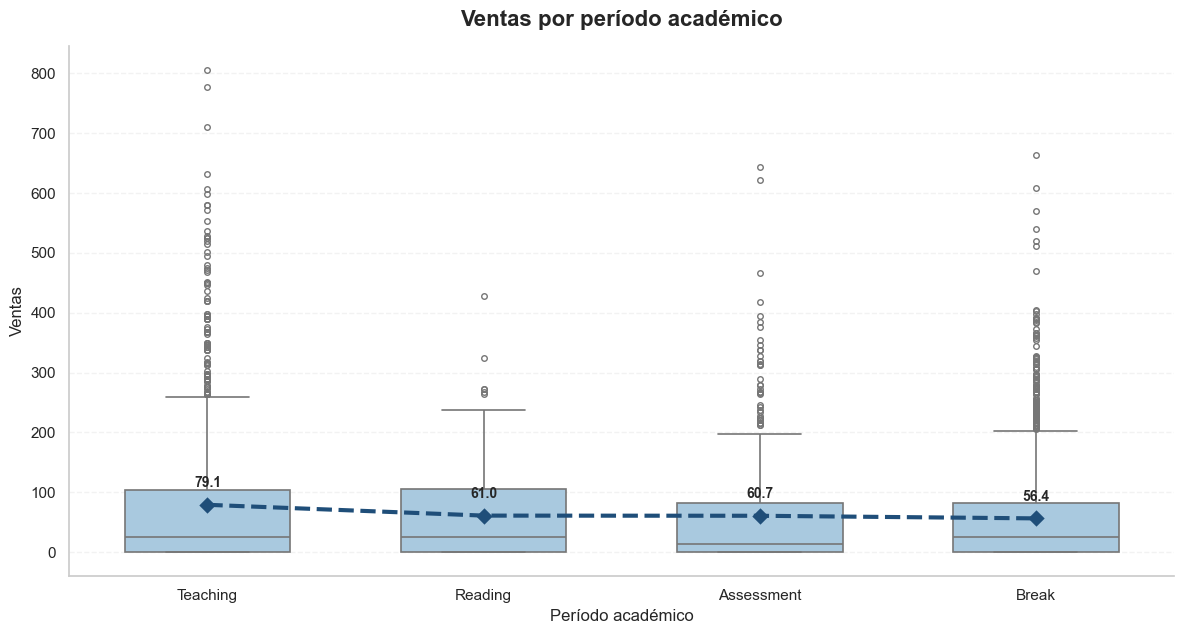

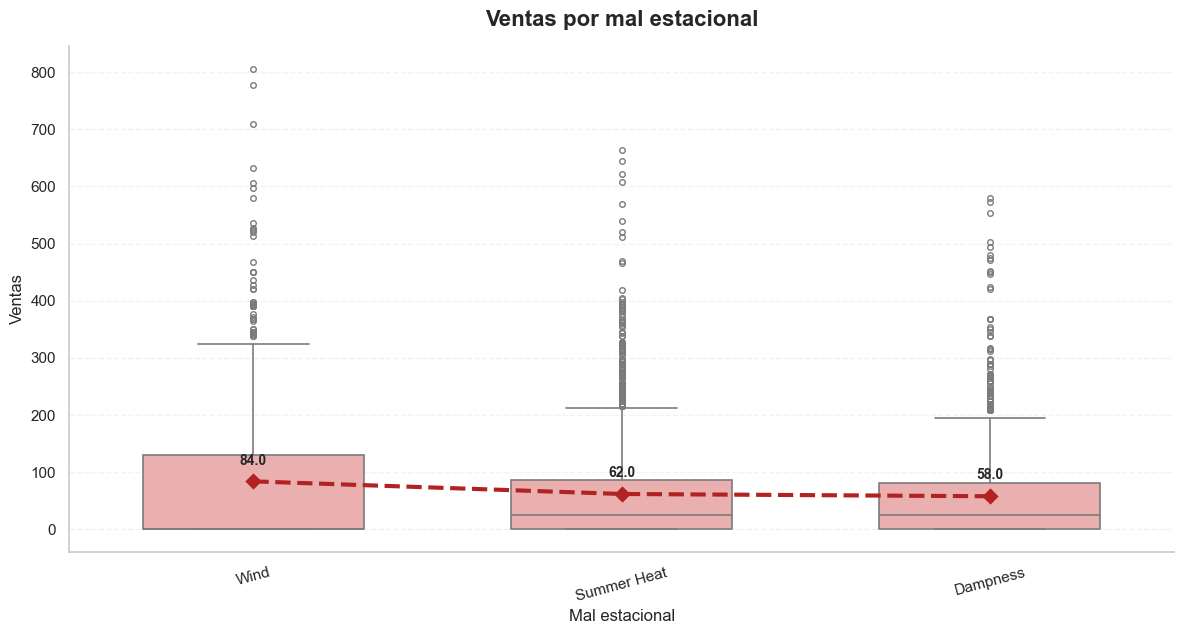

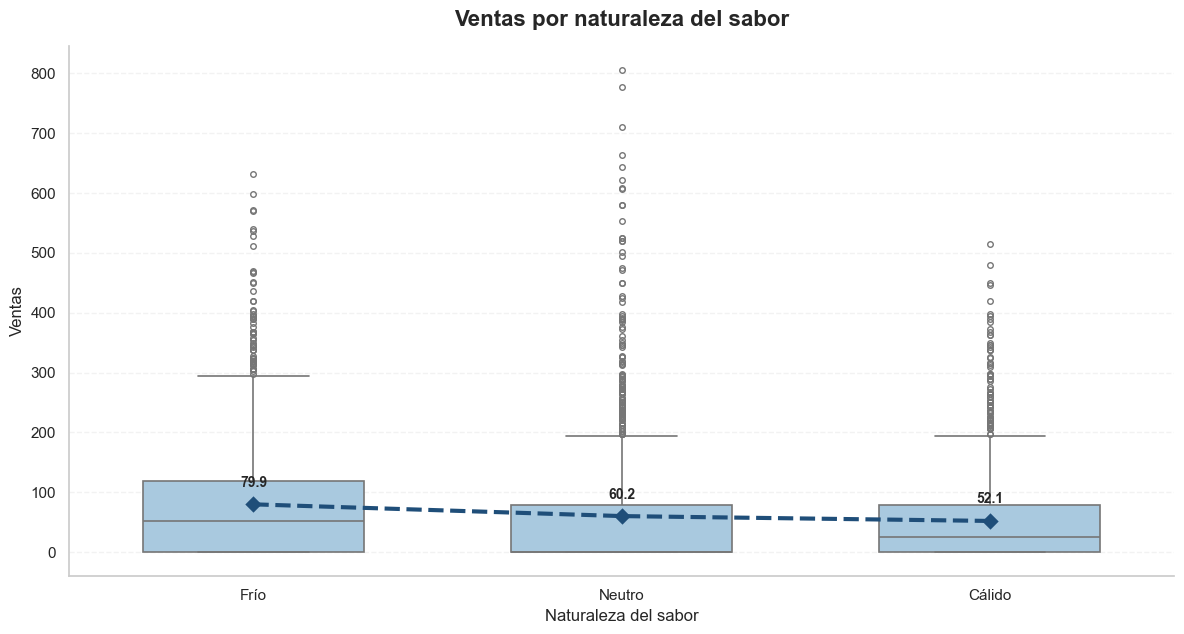

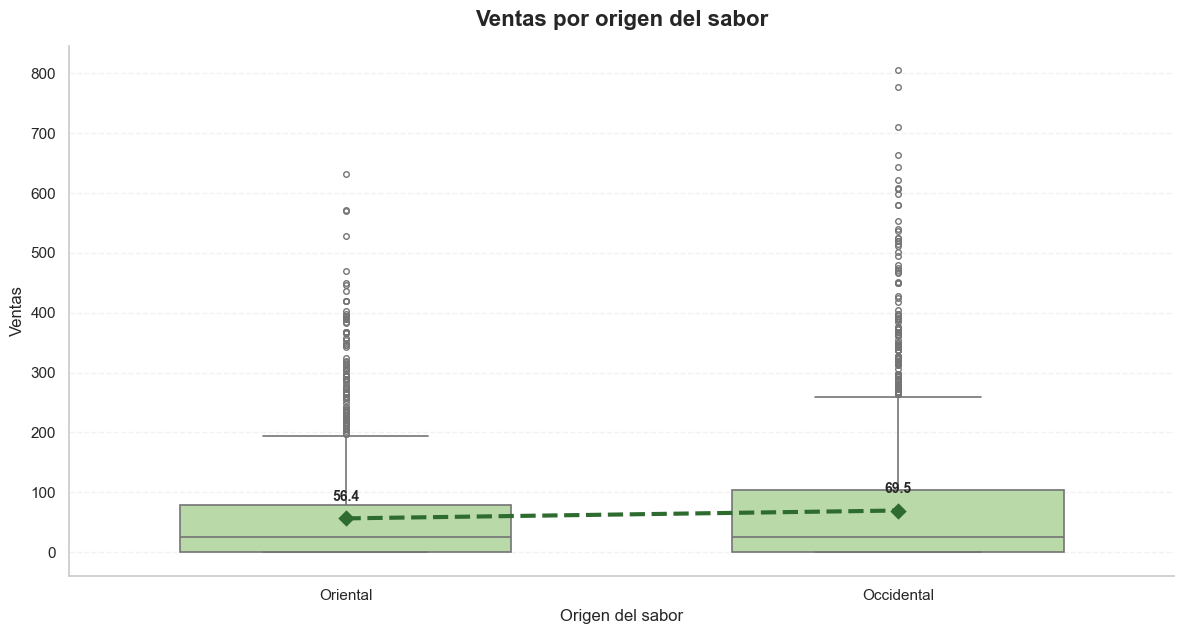

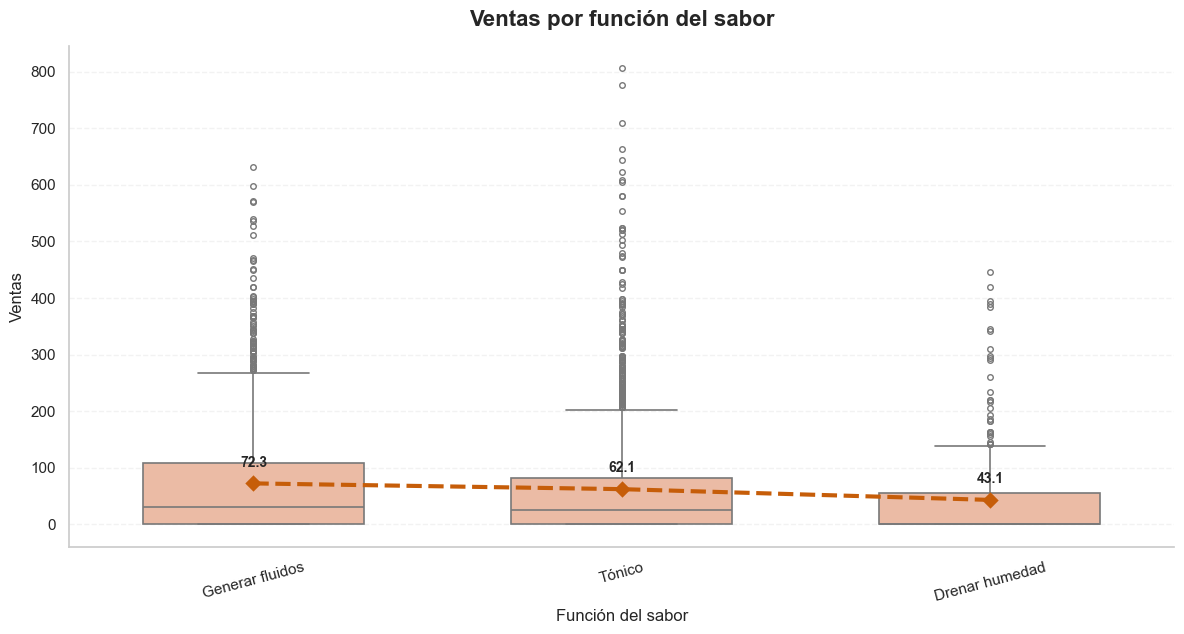

In [182]:
sns.set_theme(style="whitegrid", context="notebook")

# =========================================================
# 1. COPIA Y LIMPIEZA BÁSICA
# =========================================================
df_plot = df_model.copy()

for col in ["periodo_academico", "mal_estacional", "naturaleza_sabor", "funcion_sabor", "origen_sabor"]:
    df_plot[col] = df_plot[col].astype(str).str.strip()

# Estandarizar etiquetas
df_plot["mal_estacional"] = df_plot["mal_estacional"].replace({
    "Summer_Heat": "Summer Heat",
    "SummerHeat": "Summer Heat",
    "summer_heat": "Summer Heat"
})

df_plot["naturaleza_sabor"] = df_plot["naturaleza_sabor"].replace({
    "Frio": "Frío",
    "Calido": "Cálido"
})

df_plot["funcion_sabor"] = df_plot["funcion_sabor"].replace({
    "Generar_fluidos": "Generar fluidos",
    "Tonico": "Tónico",
    "Drenar_humedad": "Drenar humedad"
})

# =========================================================
# 2. FUNCIÓN AUXILIAR PARA CADA GRÁFICA
# =========================================================
def plot_box_mean(data, x_col, y_col, order, title, xlabel, color_box, color_line, rotate=0):
    temp = data.copy()
    temp = temp[temp[x_col].isin(order)].copy()

    resumen = (
        temp.groupby(x_col, as_index=False)[y_col]
        .mean()
    )
    resumen[x_col] = pd.Categorical(resumen[x_col], categories=order, ordered=True)
    resumen = resumen.sort_values(x_col)

    fig, ax = plt.subplots(figsize=(12, 6.5))

    sns.boxplot(
        data=temp,
        x=x_col,
        y=y_col,
        order=order,
        color=color_box,
        width=0.6,
        fliersize=4,
        linewidth=1.2,
        ax=ax
    )

    sns.pointplot(
        data=temp,
        x=x_col,
        y=y_col,
        order=order,
        estimator=np.mean,
        errorbar=None,
        color=color_line,
        markers="D",
        linestyles="--",
        scale=1.1,
        ax=ax
    )

    ymax = temp[y_col].max()

    for i, v in enumerate(resumen[y_col]):
        ax.text(
            i,
            v + ymax * 0.03,
            f"{v:,.1f}",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold"
        )

    ax.set_title(title, fontsize=16, fontweight="bold", pad=14)
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel("Ventas", fontsize=12)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", linestyle="--", alpha=0.25)
    ax.tick_params(axis="x", rotation=rotate)

    plt.tight_layout()
    plt.show()

# =========================================================
# 3. ÓRDENES
# =========================================================
orden_periodo = ["Teaching", "Reading", "Assessment", "Break"]
orden_mal = ["Wind", "Summer Heat", "Dampness"]
orden_naturaleza = ["Frío", "Neutro", "Cálido"]
orden_origen = ["Oriental", "Occidental"]
orden_funcion = ["Generar fluidos", "Tónico", "Drenar humedad"]

# =========================================================
# 4. LOS 5 GRÁFICOS GRANDES
# =========================================================

# 1) Ventas por periodo_academico
plot_box_mean(
    data=df_plot,
    x_col="periodo_academico",
    y_col="ventas",
    order=orden_periodo,
    title="Ventas por período académico",
    xlabel="Período académico",
    color_box="#A0CBE8",
    color_line="#1F4E79",
    rotate=0
)

# 2) Ventas por mal_estacional
plot_box_mean(
    data=df_plot,
    x_col="mal_estacional",
    y_col="ventas",
    order=orden_mal,
    title="Ventas por mal estacional",
    xlabel="Mal estacional",
    color_box="#F4A6A6",
    color_line="#B22222",
    rotate=15
)

# 3) Ventas por naturaleza_sabor
plot_box_mean(
    data=df_plot,
    x_col="naturaleza_sabor",
    y_col="ventas",
    order=orden_naturaleza,
    title="Ventas por naturaleza del sabor",
    xlabel="Naturaleza del sabor",
    color_box="#A0CBE8",
    color_line="#1F4E79",
    rotate=0
)

# 4) Ventas por origen_sabor
plot_box_mean(
    data=df_plot,
    x_col="origen_sabor",
    y_col="ventas",
    order=orden_origen,
    title="Ventas por origen del sabor",
    xlabel="Origen del sabor",
    color_box="#B7E1A1",
    color_line="#2E6B2E",
    rotate=0
)

# 5) Ventas por funcion_sabor
plot_box_mean(
    data=df_plot,
    x_col="funcion_sabor",
    y_col="ventas",
    order=orden_funcion,
    title="Ventas por función del sabor",
    xlabel="Función del sabor",
    color_box="#F7B799",
    color_line="#C65D09",
    rotate=15
)



En términos generales, las cinco visualizaciones sugieren que las ventas no se distribuyen de manera homogénea entre categorías, sino que presentan diferencias descriptivas que podrían ser relevantes para el problema de negocio. En todas las gráficas se observa además una dispersión considerable y una presencia importante de valores atípicos, lo que indica que el comportamiento comercial combina un nivel frecuente de ventas moderadas con algunos casos de venta mucho más alta.

*   Respecto al **período académico**, la categoría `Teaching` presenta el promedio más alto de ventas, con un valor cercano a **79.1**, mientras que `Reading`, `Assessment` y `Break` se ubican en niveles menores, alrededor de **61.0**, **60.7** y **56.4**, respectivamente. Esto sugiere que la etapa regular de clases concentra una actividad comercial más intensa que otros momentos del calendario académico.

*   En el caso del **mal estacional**, `Wind` presenta el promedio de ventas más alto, con aproximadamente **84.0**, por encima de `Summer Heat` (**62.0**) y `Dampness` (**58.0**).

*   Al analizar el **perfil del sabor**, la **naturaleza fría** muestra el promedio más alto, alrededor de **79.9**, seguida por la naturaleza **neutra** (**60.2**) y la **cálida** (**52.1**). De forma complementaria, los sabores de **origen occidental** exhiben un promedio superior (**69.5**) al de los sabores **orientales** (**56.4**). Finalmente, por **función del sabor**, la categoría **Generar fluidos** registra el mayor promedio (**72.3**), seguida de **Tónico** (**62.1**), mientras que **Drenar humedad** presenta el nivel más bajo (**43.1**).

En conjunto, estos resultados sugieren que algunas variables del contexto y del perfil del sabor sí muestran asociaciones descriptivas con el nivel de ventas. Aunque este análisis no permite establecer causalidad, sí aporta evidencia exploratoria de que variables como el período académico, la naturaleza del sabor, el origen y la función podrían contener señal útil para explicar diferencias en desempeño comercial y, por tanto, merecen ser consideradas en las siguientes fases del proyecto.

### **13.11. Relaciones entre variables explicativas:**

Una vez analizadas por separado las variables temporales y las características del sabor, el siguiente paso consiste en examinar cómo interactúan entre sí. Esta etapa del análisis exploratorio busca identificar patrones conjuntos entre la temporalidad del negocio, el portafolio de sabores y el contexto conceptual construido a partir de la Medicina Tradicional China.

Para ello, se presentan cuatro visualizaciones complementarias. En primer lugar, un heatmap de `mes × sabor`, que permite observar cómo cambia el promedio de ventas de cada sabor a lo largo del período analizado. En segundo lugar, un heatmap de `periodo_academico × sabor`, orientado a evaluar si ciertos sabores muestran mejor desempeño en momentos específicos del calendario universitario. En tercer lugar, se analiza la relación entre `mal_estacional` y `naturaleza_sabor`, con el fin de explorar si algunos perfiles térmicos parecen alinearse mejor con determinadas condiciones estacionales. Finalmente, se estudia la combinación entre `periodo_academico` y `dia_de_semana`, para identificar si existen rutinas semanales distintas según el momento académico.

Este bloque es especialmente importante porque conecta directamente la pregunta de negocio con la lógica del proyecto. Más allá de describir variables por separado, estas gráficas permiten observar si la demanda parece responder a una interacción entre el momento del semestre, el tipo de sabor y el contexto estacional, lo cual constituye una señal relevante para justificar el posterior uso de estas variables en el modelado predictivo.

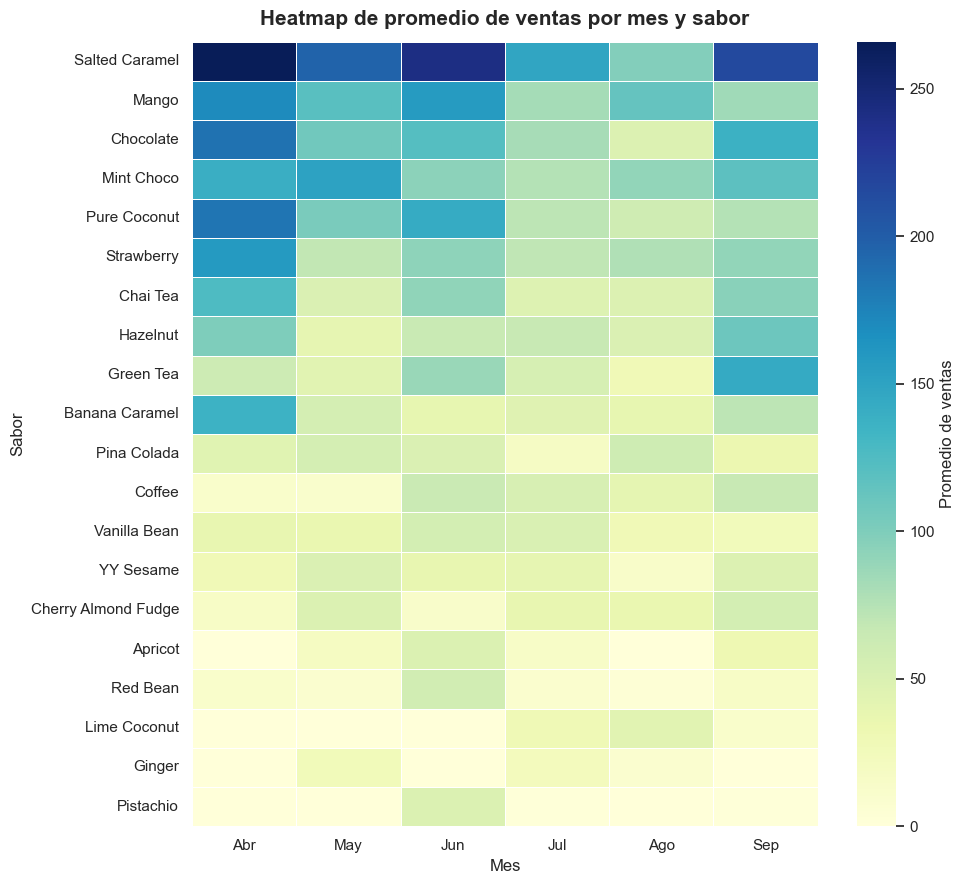

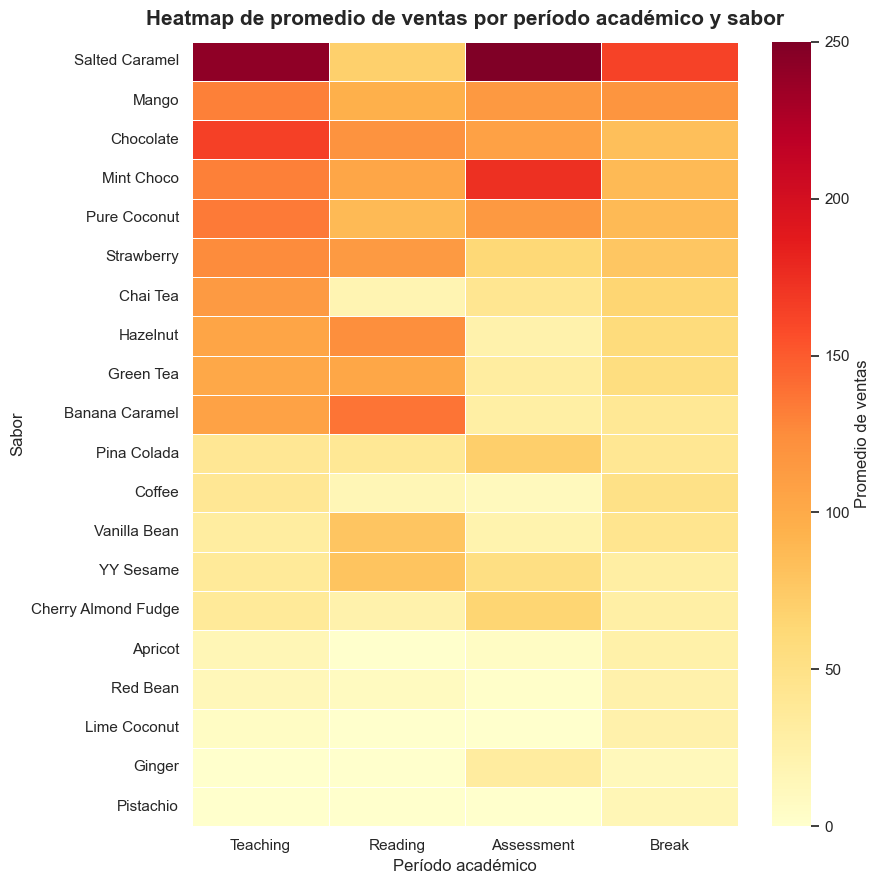

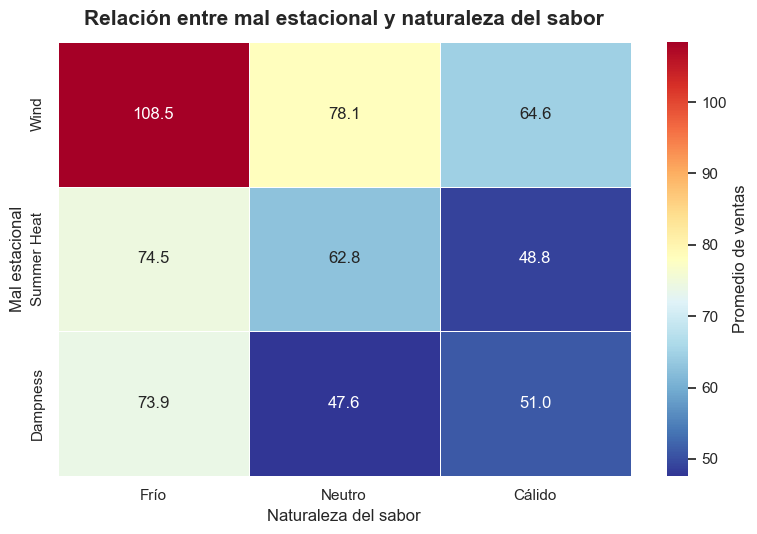

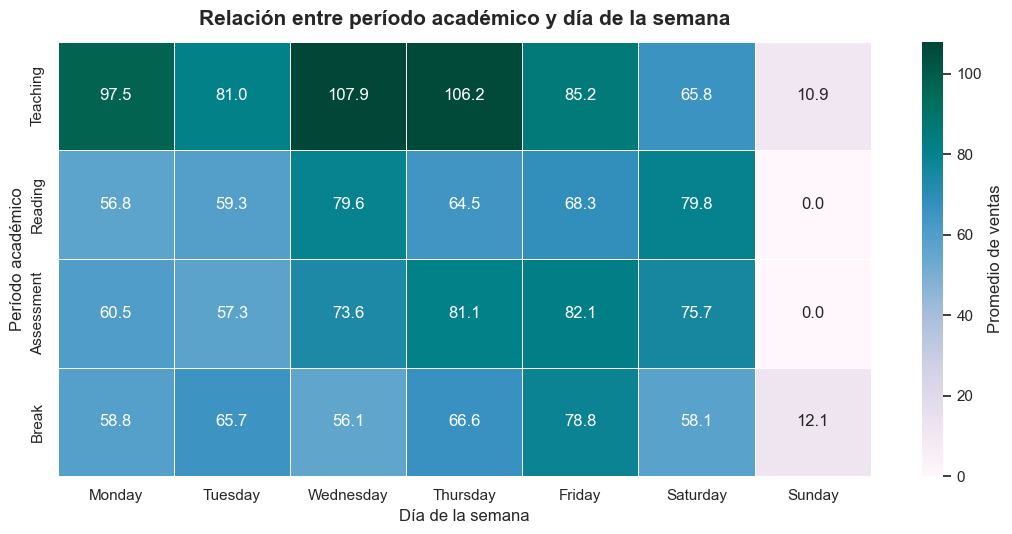

In [183]:
# =========================================================
# CONFIGURACIÓN GENERAL
# =========================================================
sns.set_theme(style="whitegrid", context="notebook")

plot_df = df_model.copy()
plot_df["mes_num"] = plot_df["fecha"].dt.month

# =========================================================
# LIMPIEZA BÁSICA DE ETIQUETAS
# =========================================================
for col in ["sabor", "periodo_academico", "mal_estacional", "naturaleza_sabor", "dia_de_semana"]:
    plot_df[col] = plot_df[col].astype(str).str.strip()

plot_df["mal_estacional"] = plot_df["mal_estacional"].replace({
    "Summer_Heat": "Summer Heat",
    "SummerHeat": "Summer Heat",
    "summer_heat": "Summer Heat"
})

plot_df["naturaleza_sabor"] = plot_df["naturaleza_sabor"].replace({
    "Frio": "Frío",
    "Calido": "Cálido"
})

# =========================================================
# ÓRDENES
# =========================================================
mapa_meses = {
    4: "Abr", 5: "May", 6: "Jun",
    7: "Jul", 8: "Ago", 9: "Sep"
}
orden_meses = ["Abr", "May", "Jun", "Jul", "Ago", "Sep"]
orden_periodo = ["Teaching", "Reading", "Assessment", "Break"]
orden_mal = ["Wind", "Summer Heat", "Dampness"]   # <- quitamos Dryness y Cold
orden_naturaleza = ["Frío", "Neutro", "Cálido"]
orden_dias = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

plot_df["mes_label"] = plot_df["mes_num"].map(mapa_meses)

# Orden de sabores por ventas totales
orden_sabores = (
    plot_df.groupby("sabor")["ventas"]
    .sum()
    .sort_values(ascending=False)
    .index
)

# =========================================================
# 1) HEATMAP MES × SABOR
# =========================================================
tabla_mes_sabor = pd.pivot_table(
    plot_df,
    index="sabor",
    columns="mes_label",
    values="ventas",
    aggfunc="mean"
).reindex(index=orden_sabores, columns=orden_meses)

plt.figure(figsize=(10, 9))
sns.heatmap(
    tabla_mes_sabor,
    cmap="YlGnBu",
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "Promedio de ventas"}
)
plt.title("Heatmap de promedio de ventas por mes y sabor", fontsize=15, weight="bold", pad=12)
plt.xlabel("Mes")
plt.ylabel("Sabor")
plt.tight_layout()
plt.show()

# =========================================================
# 2) HEATMAP PERIODO ACADÉMICO × SABOR
# =========================================================
tabla_periodo_sabor = pd.pivot_table(
    plot_df,
    index="sabor",
    columns="periodo_academico",
    values="ventas",
    aggfunc="mean"
).reindex(index=orden_sabores, columns=orden_periodo)

plt.figure(figsize=(9, 9))
sns.heatmap(
    tabla_periodo_sabor,
    cmap="YlOrRd",
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "Promedio de ventas"}
)
plt.title("Heatmap de promedio de ventas por período académico y sabor", fontsize=15, weight="bold", pad=12)
plt.xlabel("Período académico")
plt.ylabel("Sabor")
plt.tight_layout()
plt.show()

# =========================================================
# 3) HEATMAP MAL ESTACIONAL × NATURALEZA DEL SABOR
#    SIN DRYNESS NI COLD
# =========================================================
plot_mtc = plot_df[plot_df["mal_estacional"].isin(orden_mal)].copy()

tabla_mal_nat = pd.pivot_table(
    plot_mtc,
    index="mal_estacional",
    columns="naturaleza_sabor",
    values="ventas",
    aggfunc="mean"
).reindex(index=orden_mal, columns=orden_naturaleza)

plt.figure(figsize=(8, 5.5))
sns.heatmap(
    tabla_mal_nat,
    annot=True,
    fmt=".1f",
    cmap="RdYlBu_r",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Promedio de ventas"}
)
plt.title("Relación entre mal estacional y naturaleza del sabor", fontsize=15, weight="bold", pad=12)
plt.xlabel("Naturaleza del sabor")
plt.ylabel("Mal estacional")
plt.tight_layout()
plt.show()

# =========================================================
# 4) HEATMAP PERIODO ACADÉMICO × DÍA DE LA SEMANA
# =========================================================
tabla_periodo_dia = pd.pivot_table(
    plot_df,
    index="periodo_academico",
    columns="dia_de_semana",
    values="ventas",
    aggfunc="mean"
).reindex(index=orden_periodo, columns=orden_dias)

plt.figure(figsize=(11, 5.5))
sns.heatmap(
    tabla_periodo_dia,
    annot=True,
    fmt=".1f",
    cmap="PuBuGn",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Promedio de ventas"}
)
plt.title("Relación entre período académico y día de la semana", fontsize=15, weight="bold", pad=12)
plt.xlabel("Día de la semana")
plt.ylabel("Período académico")
plt.tight_layout()
plt.show()



Las visualizaciones conjuntas muestran que el comportamiento de las ventas no depende únicamente de una variable aislada, sino de combinaciones específicas entre tiempo, sabor y contexto. En el heatmap de `mes × sabor` se observa que varios sabores presentan una intensidad claramente mayor en abril y, en menor medida, en junio y septiembre, mientras que julio y agosto concentran niveles más bajos para buena parte del portafolio. Además, algunos sabores destacan de forma consistente por encima del resto, como **Salted Caramel**, **Mango**, **Chocolate** y **Mint Choco**, lo que sugiere que el componente temporal no afecta a todos los productos de la misma manera.

*    El heatmap de `periodo_academico × sabor` refuerza esta lectura. La categoría `Teaching` concentra varios de los promedios más altos de ventas para muchos sabores, mientras que `Break` tiende a mostrar niveles más moderados. También se observan algunos casos en los que determinados sabores mantienen buen desempeño en más de un período, pero con distinta intensidad. Esto sugiere que el calendario académico sí introduce variación en la demanda y que dicha variación interactúa con la identidad específica del sabor.

*    En la relación entre `mal_estacional` y `naturaleza_sabor` aparecen diferencias descriptivas interesantes. Bajo `Wind`, la naturaleza **Frío** presenta el promedio más alto de ventas, seguida por **Neutro** y luego **Cálido**. En `Summer Heat`, las tres naturalezas bajan, pero **Frío** sigue ubicándose por encima de las demás. En `Dampness`, la categoría **Frío** vuelve a liderar, mientras que **Neutro** y **Cálido** se sitúan más abajo. Aunque este patrón no constituye una validación causal de la hipótesis MTC, sí sugiere que la relación entre contexto estacional y perfil térmico del sabor merece ser considerada con atención en el análisis posterior.

*    Finalmente, el heatmap de `periodo_academico × dia_de_semana` muestra que la rutina semanal cambia según el momento académico. Durante `Teaching`, los promedios más altos se concentran entre **miércoles**, **jueves** y **lunes**, mientras que el domingo presenta un nivel muy bajo. En `Reading` y `Assessment`, la intensidad general disminuye, pero siguen destacándose algunos días específicos, especialmente **viernes** y **sábado** en ciertos tramos. En `Break`, el patrón semanal se suaviza, aunque **viernes** continúa mostrando un nivel relativamente alto frente a otros días. En conjunto, estos resultados sugieren que la dinámica comercial responde a una estructura temporal combinada: no solo importa el mes o el período académico, sino también el día específico dentro de ese contexto.

En síntesis, este bloque aporta evidencia exploratoria de que la demanda local parece estar influida por interacciones entre el momento del semestre, la estacionalidad y el perfil del sabor. Esto fortalece la lógica del proyecto, ya que muestra que las variables construidas no solo tienen sentido conceptual, sino que también exhiben patrones conjuntos observables en los datos.

In [184]:
print(df_model.head())

       fecha                sabor  ventas  dia_del_año dia_de_semana  \
0 2017-04-01              Apricot     0.0           91      Saturday   
1 2017-04-01       Banana Caramel    26.0           91      Saturday   
2 2017-04-01             Chai Tea   104.0           91      Saturday   
3 2017-04-01  Cherry Almond Fudge     0.0           91      Saturday   
4 2017-04-01            Chocolate   186.0           91      Saturday   

  periodo_academico mal_estacional naturaleza_sabor    funcion_sabor  \
0          Teaching           Wind           Neutro  Generar_fluidos   
1          Teaching           Wind           Neutro           Tonico   
2          Teaching           Wind           Calido   Drenar_humedad   
3          Teaching           Wind           Calido           Tonico   
4          Teaching           Wind           Calido           Tonico   

  origen_sabor  top_seller  
0   Occidental           0  
1   Occidental           0  
2     Oriental           0  
3   Occidental    

## 14 KPIs

| KPI | Definición | Fórmula |
|---|---|---|
| **Precisión del modelo** | De los sabores que el modelo predice como top sellers, ¿qué porcentaje realmente lo son? | TP / (TP + FP) |
| **Tasa de merma semanal** | Porcentaje de días en que un sabor predicho como top seller por el modelo no aparece en el top 5 real de ventas del segmento local ese día | Días con FP / Total días con recomendación |
| **Alineación MTC** | Porcentaje de los top sellers reales que tienen perfil MTC alineado con el mal estacional de ese día | Top sellers MTC-alineados / Total top sellers reales |
| **Recall del modelo** | De todos los top sellers reales, ¿qué porcentaje detectó el modelo? | TP / (TP + FN) |

## 15 OKRs del proyecto

Los OKRs traducen los KPIs en compromisos estratégicos medibles para Mary y su equipo.

---

**Objective:** Optimizar el portafolio diario de sabores para el segmento local de HKU
mediante un modelo de clasificación basado en MTC y contexto académico.

**KR1 — Precisión operativa del modelo**  
Lograr que al menos el **65%** de los sabores predichos como top sellers por el modelo
estén efectivamente en el top 5 de ventas reales del segmento local ese día.

*Razonamiento:* este resultado significa que por cada 10 recomendaciones del modelo,
al menos 6 o 7 son correctas. Con un portafolio de 5 sabores en carta, eso reduce
significativamente la probabilidad de merma comparado con la selección manual actual.

**KR2 — Reducción de merma por stock ineficiente**  
Reducir en un **30%** la frecuencia de días en que un sabor predicho como top seller por el modelo queda fuera del top 5 de ventas reales del segmento local ese día.

*Razonamiento:* este resultado se mide comparando el comportamiento de los sabores
seleccionados con el modelo versus la selección histórica sin modelo. Una reducción
del 30% implica menos producto preparado sin vender y menor costo de obsolescencia.

**KR3 — Validación de la hipótesis MTC como driver de compra**  
Que al menos el **70%** de los top sellers reales del período de evaluación tengan
un perfil MTC alineado con el mal estacional de ese día.

*Razonamiento:* este resultado no depende del modelo sino de los datos históricos
reales. Si se cumple, Happy Cow tiene evidencia cuantitativa de que la alineación
cultural del portafolio justifica convertir la estrategia MTC en una política
permanente de gestión del portafolio.


---

| OKR | KR | Meta | Cómo se mide |
|---|---|---|---|
| Optimizar portafolio local HKU | KR1: Precisión del modelo | ≥ 65% | Métricas del modelo sobre set de prueba |
| Optimizar portafolio local HKU | KR2: Reducción de merma | −30% días con FP sobre set de prueba | Simulación retrospectiva vs. línea base sin modelo |
| Optimizar portafolio local HKU | KR3: Validación MTC | ≥ 70% top sellers alineados MTC | Análisis descriptivo sobre df_model |


---
## **16. Modelado**

Esta sección implementa el modelo de clasificación siguiendo una arquitectura de **Stacking**:

| Nivel | Modelo | Rol |
|---|---|---|
| Base 1 | Regresión Logística | Captura relaciones lineales |
| Base 2 | Árbol de Decisión (prof. 3) | Captura interacciones no lineales, interpretable |
| Meta-modelo | Regresión Logística | Aprende a combinar las predicciones de los modelos base |

Se incorporan **features de serie de tiempo** por sabor (ventas del día anterior, promedios móviles, tasas históricas de éxito) que aportan información predictiva real sobre el comportamiento reciente de cada sabor. El split se hace por días completos usando `StratifiedGroupKFold` para evitar que el mismo día quede partido entre train y test.

### **16.1 Librerías de modelado**

In [185]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedGroupKFold, GroupShuffleSplit
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score, accuracy_score,
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
)

RANDOM_STATE = 42
print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


### **16.2 Feature engineering — variables de serie de tiempo**

Se construyen variables históricas por sabor usando únicamente información anterior al día actual (`shift(1)`). Esto evita *data leakage*: el modelo nunca ve las ventas del mismo día que intenta predecir.

Las variables generadas capturan el comportamiento reciente de cada sabor:
- `ventas_lag_1`: ventas del día anterior
- `top_lag_1`: si fue top seller el día anterior
- Promedios móviles de ventas en ventanas de 3, 7, 14 y 28 días
- Tasas históricas de éxito como top seller en las mismas ventanas
- Promedios históricos acumulados desde el inicio del período

También se agregan variables cíclicas (seno y coseno del día y semana del año) para que el modelo capture la continuidad temporal sin asumir linealidad.

In [186]:
df_ml = df_model.copy()
df_ml["fecha"] = pd.to_datetime(df_ml["fecha"], errors="coerce")
df_ml = df_ml.sort_values(["sabor", "fecha"]).reset_index(drop=True)

# Recalcular top_seller con rank para mayor robustez
df_ml["rank_dia"] = (
    df_ml.groupby("fecha")["ventas"]
    .rank(method="first", ascending=False)
)
df_ml["top_seller"] = (df_ml["rank_dia"] <= 5).astype(int)
df_ml = df_ml.drop(columns=["rank_dia"])

# Variables calendario
df_ml["mes"]           = df_ml["fecha"].dt.month
df_ml["semana_del_año"] = df_ml["fecha"].dt.isocalendar().week.astype(int)

# Variables cíclicas
df_ml["dia_sin"]    = np.sin(2 * np.pi * df_ml["dia_del_año"] / 365)
df_ml["dia_cos"]    = np.cos(2 * np.pi * df_ml["dia_del_año"] / 365)
df_ml["semana_sin"] = np.sin(2 * np.pi * df_ml["semana_del_año"] / 52)
df_ml["semana_cos"] = np.cos(2 * np.pi * df_ml["semana_del_año"] / 52)

# Features históricas por sabor (shift(1) = solo información anterior)
g = df_ml.groupby("sabor", group_keys=False)

df_ml["ventas_lag_1"] = g["ventas"].shift(1)
df_ml["top_lag_1"]    = g["top_seller"].shift(1)

for w in [3, 7, 14, 28]:
    df_ml[f"ventas_roll_mean_{w}"] = g["ventas"].transform(
        lambda s: s.shift(1).rolling(window=w, min_periods=1).mean())
    df_ml[f"ventas_roll_sum_{w}"] = g["ventas"].transform(
        lambda s: s.shift(1).rolling(window=w, min_periods=1).sum())
    df_ml[f"top_rate_roll_{w}"] = g["top_seller"].transform(
        lambda s: s.shift(1).rolling(window=w, min_periods=1).mean())

df_ml["ventas_expanding_mean"] = g["ventas"].transform(
    lambda s: s.shift(1).expanding(min_periods=1).mean())
df_ml["top_expanding_rate"] = g["top_seller"].transform(
    lambda s: s.shift(1).expanding(min_periods=1).mean())

# Rellenar NaN iniciales con 0
cols_hist = (["ventas_lag_1", "top_lag_1", "ventas_expanding_mean", "top_expanding_rate"] +
             [f"{p}_{w}" for p in ["ventas_roll_mean","ventas_roll_sum","top_rate_roll"]
              for w in [3,7,14,28]])
df_ml[cols_hist] = df_ml[cols_hist].fillna(0)

df_ml = df_ml.sort_values(["fecha", "sabor"]).reset_index(drop=True)

print("Base con features de serie de tiempo:")
print(f"  Filas: {df_ml.shape[0]} | Columnas: {df_ml.shape[1]}")
print(f"  Días únicos: {df_ml['fecha'].nunique()}")
print(f"  Sabores únicos: {df_ml['sabor'].nunique()}")
print(f"  Proporción top_seller: {df_ml['top_seller'].mean():.2%}")

Base con features de serie de tiempo:
  Filas: 3660 | Columnas: 33
  Días únicos: 183
  Sabores únicos: 20
  Proporción top_seller: 25.00%


### **16.3 Definición de variables predictoras y preprocesamiento**

Se usa `OneHotEncoder` para las variables categóricas y `StandardScaler` para las numéricas, dentro de un `ColumnTransformer`. Esto garantiza que el preprocesamiento forme parte del pipeline y no haya leakage entre train y test.

In [187]:
target = "top_seller"

numeric_features = [
    "dia_del_año", "mes", "semana_del_año",
    "dia_sin", "dia_cos", "semana_sin", "semana_cos",
    "ventas_lag_1", "top_lag_1",
    "ventas_expanding_mean", "top_expanding_rate",
    "ventas_roll_mean_3",  "ventas_roll_sum_3",  "top_rate_roll_3",
    "ventas_roll_mean_7",  "ventas_roll_sum_7",  "top_rate_roll_7",
    "ventas_roll_mean_14", "ventas_roll_sum_14", "top_rate_roll_14",
    "ventas_roll_mean_28", "ventas_roll_sum_28", "top_rate_roll_28"
]

categorical_features = [
    "sabor", "dia_de_semana", "periodo_academico",
    "mal_estacional", "naturaleza_sabor", "funcion_sabor", "origen_sabor"
]

features = numeric_features + categorical_features

X = df_ml[features].copy()
y = df_ml[target].copy()
groups = df_ml["fecha"].copy()

try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", ohe, categorical_features)
    ],
    remainder="drop"
)

print("Variables numéricas:", len(numeric_features))
print("Variables categóricas:", len(categorical_features))
print("Total features:", len(features))

Variables numéricas: 23
Variables categóricas: 7
Total features: 30


### **16.4 División train/test por días completos**

Se usa `StratifiedGroupKFold` con `groups=fecha`. Esto garantiza que todos los sabores de un mismo día queden en el mismo conjunto (train o test), evitando que el modelo vea el contexto de un día en entrenamiento y lo prediga en prueba. Si no está disponible, se usa `GroupShuffleSplit` como alternativa.

In [188]:
try:
    sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    train_idx, test_idx = next(sgkf.split(X, y, groups=groups))
    split_usado = "StratifiedGroupKFold por fecha"
except Exception as e:
    print("Usando GroupShuffleSplit:", e)
    gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)
    train_idx, test_idx = next(gss.split(X, y, groups=groups))
    split_usado = "GroupShuffleSplit por fecha"

X_train = X.iloc[train_idx].copy()
X_test  = X.iloc[test_idx].copy()
y_train = y.iloc[train_idx].copy()
y_test  = y.iloc[test_idx].copy()
df_train = df_ml.iloc[train_idx].copy()
df_test  = df_ml.iloc[test_idx].copy()

print(f"Split: {split_usado}")
print(f"Train: {X_train.shape[0]} filas | {df_train['fecha'].nunique()} días")
print(f"Test:  {X_test.shape[0]}  filas | {df_test['fecha'].nunique()} días")
print(f"Proporción top_seller train: {y_train.mean():.2%}")
print(f"Proporción top_seller test:  {y_test.mean():.2%}")

Split: StratifiedGroupKFold por fecha
Train: 2920 filas | 146 días
Test:  740  filas | 37 días
Proporción top_seller train: 25.00%
Proporción top_seller test:  25.00%


### **16.5 Entrenamiento del Stacking**

El `StackingClassifier` usa validación cruzada interna de 5 folds para generar predicciones *out-of-fold* de los modelos base, evitando que el meta-modelo aprenda sobre datos que los modelos base ya vieron. `passthrough=False` obliga al meta-modelo a trabajar exclusivamente con las predicciones de los modelos base.

In [189]:
from sklearn.ensemble import StackingClassifier, RandomForestClassifier

stacking_estimators = [
    ("lr", LogisticRegression(
        max_iter=3000, C=0.7,
        class_weight="balanced",
        random_state=RANDOM_STATE
    )),
    ("dt", DecisionTreeClassifier(
        max_depth=3, min_samples_leaf=20,
        class_weight="balanced",
        random_state=RANDOM_STATE
    )),
    ("rf", RandomForestClassifier(
        n_estimators=400,
        max_depth=12,
        min_samples_leaf=5,
        max_features="sqrt",
        class_weight={0: 1.0, 1: 1.6},
        random_state=RANDOM_STATE,
        n_jobs=-1
    )),
]

modelo_final = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", StackingClassifier(
        estimators=stacking_estimators,
        final_estimator=LogisticRegression(
            max_iter=3000, class_weight="balanced",
            random_state=RANDOM_STATE
        ),
        cv=5,
        passthrough=False,
        n_jobs=-1
    ))
])

print("Entrenando Stacking (LR + DT + RF, meta LR)...")
modelo_final.fit(X_train, y_train)
prob_final = modelo_final.predict_proba(X_test)[:, 1]
print("Entrenamiento completado.")

Entrenando Stacking (LR + DT + RF, meta LR)...
Entrenamiento completado.


### **16.6 Análisis de threshold**

Se evalúa cómo varían Precisión, Recall y F1 al cambiar el umbral de decisión de 0.00 a 1.00. El threshold óptimo se selecciona automáticamente como el que maximiza el F1, que balancea ambas métricas. Desde el negocio, un threshold más alto reduce la merma (mayor Precisión) a costa de perder más oportunidades de venta (menor Recall).

In [190]:
def tabla_thresholds(y_true, y_prob):
    rows = []
    for t in np.round(np.arange(0.00, 1.0001, 0.01), 2):
        pred = (y_prob >= t).astype(int)
        rows.append({
            "threshold": float(f"{t:.2f}"),
            "accuracy" : accuracy_score(y_true, pred),
            "precision": precision_score(y_true, pred, zero_division=0),
            "recall"   : recall_score(y_true, pred, zero_division=0),
            "f1"       : f1_score(y_true, pred, zero_division=0),
            "positivos_predichos": int(pred.sum())
        })
    return pd.DataFrame(rows)

threshold_df = tabla_thresholds(y_test, prob_final)
best_row = threshold_df.sort_values(["f1","precision","recall"], ascending=False).iloc[0]
threshold_final = float(best_row["threshold"])
pred_final = (prob_final >= threshold_final).astype(int)

print(f"Threshold óptimo por F1: {threshold_final:.2f}")
print()
print("=== Reporte de clasificación ===")
print(classification_report(y_test, pred_final,
      target_names=["No top seller", "Top seller"], zero_division=0))

Threshold óptimo por F1: 0.47

=== Reporte de clasificación ===
               precision    recall  f1-score   support

No top seller       0.92      0.79      0.85       555
   Top seller       0.55      0.79      0.65       185

     accuracy                           0.79       740
    macro avg       0.73      0.79      0.75       740
 weighted avg       0.83      0.79      0.80       740



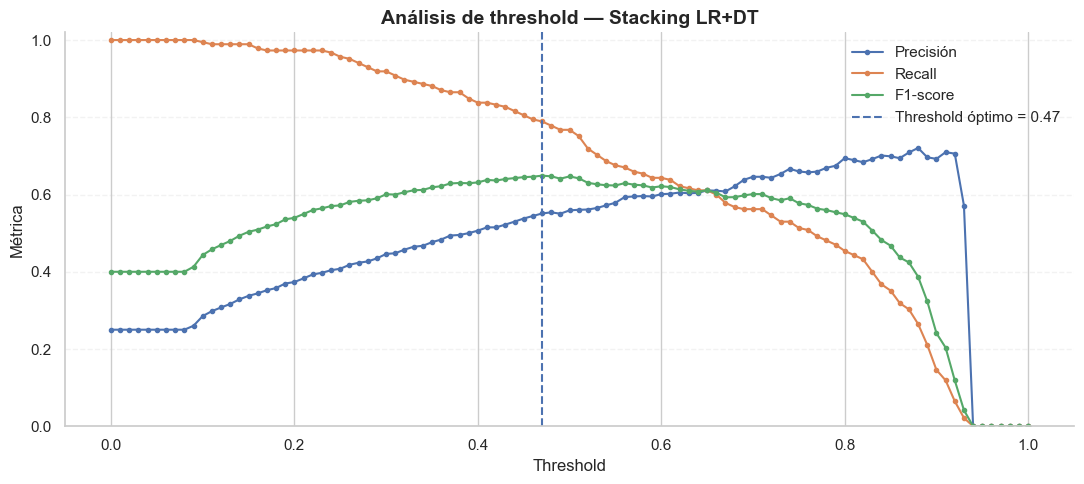

In [191]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(threshold_df["threshold"], threshold_df["precision"], marker="o", markersize=3, label="Precisión")
ax.plot(threshold_df["threshold"], threshold_df["recall"],    marker="o", markersize=3, label="Recall")
ax.plot(threshold_df["threshold"], threshold_df["f1"],        marker="o", markersize=3, label="F1-score")
ax.axvline(threshold_final, linestyle="--", linewidth=1.5,
           label=f"Threshold óptimo = {threshold_final:.2f}")
ax.set_title("Análisis de threshold — Stacking LR+DT", fontsize=14, fontweight="bold")
ax.set_xlabel("Threshold"); ax.set_ylabel("Métrica"); ax.set_ylim(0, 1.02)
ax.grid(axis="y", linestyle="--", alpha=0.25)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

### **16.7 Matriz de confusión**

La matriz de confusión muestra la distribución de aciertos y errores del modelo. Los **Falsos Positivos** (predijo top seller pero no lo fue) representan el costo operativo directo para Mary: producto preparado sin vender. Los **Falsos Negativos** (no predijo top seller pero sí lo fue) representan oportunidades de venta perdidas.

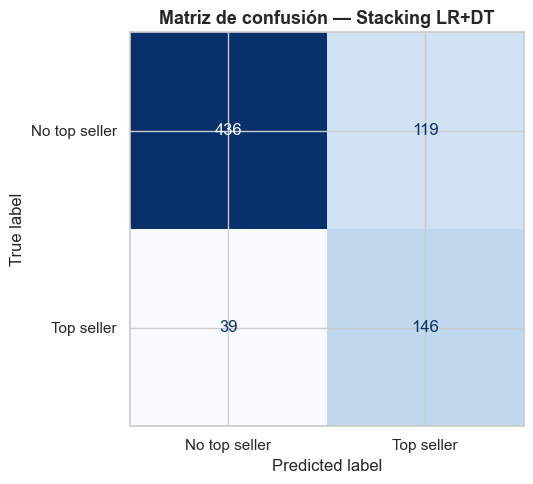

In [192]:
cm = confusion_matrix(y_test, pred_final)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=["No top seller", "Top seller"]).plot(
    ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Matriz de confusión — Stacking LR+DT", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

### **16.8 Curvas ROC y Precision-Recall**

La **curva ROC** muestra el trade-off entre la tasa de verdaderos positivos y la de falsos positivos a distintos thresholds. El **AUC** resume el desempeño global: 1.0 es perfecto, 0.5 es aleatorio.

La **curva Precision-Recall** es más informativa que la ROC cuando las clases están desbalanceadas, como en este caso (75/25). El **Average Precision** resume el área bajo esta curva.

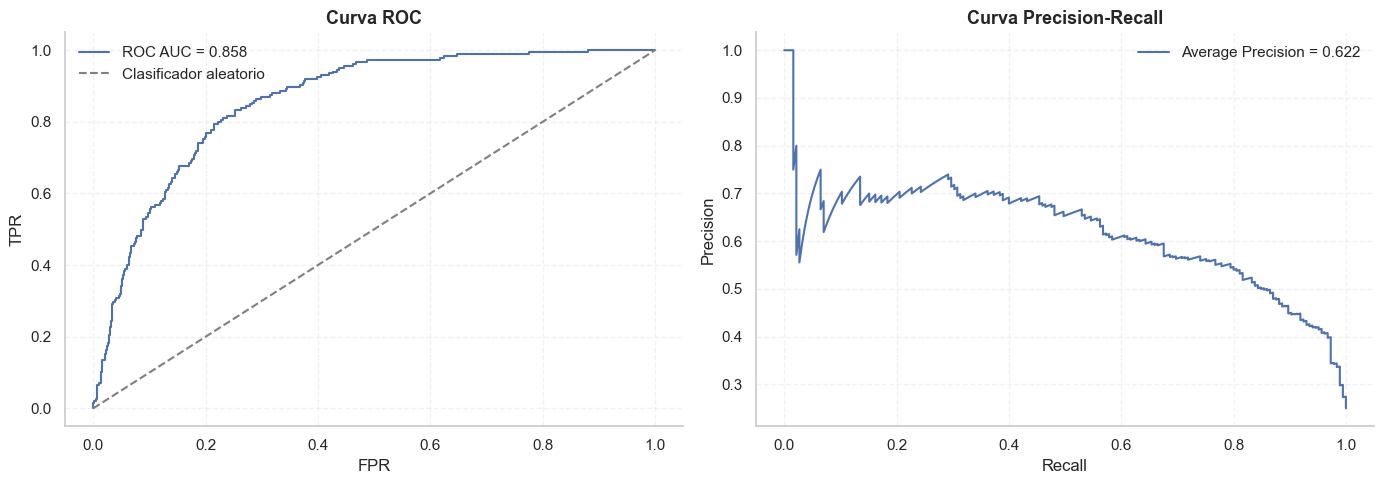

ROC AUC:           0.858
Average Precision: 0.622


In [193]:
fpr, tpr, _ = roc_curve(y_test, prob_final)
prec_curve, rec_curve, _ = precision_recall_curve(y_test, prob_final)
roc_auc = roc_auc_score(y_test, prob_final)
ap_score = average_precision_score(y_test, prob_final)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.3f}")
axes[0].plot([0,1],[0,1], linestyle="--", color="gray", label="Clasificador aleatorio")
axes[0].set_title("Curva ROC", fontsize=13, fontweight="bold")
axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR")
axes[0].legend(frameon=False); axes[0].grid(linestyle="--", alpha=0.25)
axes[0].spines["top"].set_visible(False); axes[0].spines["right"].set_visible(False)

axes[1].plot(rec_curve, prec_curve, label=f"Average Precision = {ap_score:.3f}")
axes[1].set_title("Curva Precision-Recall", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].legend(frameon=False); axes[1].grid(linestyle="--", alpha=0.25)
axes[1].spines["top"].set_visible(False); axes[1].spines["right"].set_visible(False)
plt.tight_layout(); plt.show()

print(f"ROC AUC:           {roc_auc:.3f}")
print(f"Average Precision: {ap_score:.3f}")

### **16.9 Evaluación operacional — Precision@5 por día**

Además de las métricas estándar de clasificación, se evalúa el modelo en términos operacionales: de los 5 sabores que el modelo recomienda por día (los de mayor probabilidad), ¿cuántos coinciden con los 5 top sellers reales?

Esta métrica es más cercana a la realidad de Mary: ella no clasifica todos los sabores individualmente sino que elige cuántos poner en carta.

In [194]:
def evaluar_topk_por_dia(df_eval, y_prob, k=5):
    tmp = df_eval.copy()
    tmp["prob_top_seller"] = y_prob
    total_hits = total_dias = dias_3_hits = fp_modelo = 0
    detalle = []
    for fecha, dia_df in tmp.groupby("fecha"):
        total_dias += 1
        reales       = set(dia_df.sort_values("ventas", ascending=False).head(k)["sabor"])
        recomendados = set(dia_df.sort_values("prob_top_seller", ascending=False).head(k)["sabor"])
        hits = len(reales & recomendados)
        total_hits += hits
        fp_modelo  += k - hits
        if hits >= 3: dias_3_hits += 1
        detalle.append({"fecha": fecha, "hits_top5": hits, "fp_top5": k - hits,
                        "precision_at_5_dia": hits / k})
    return {
        "precision_at_5": total_hits / (total_dias * k) if total_dias else 0,
        "avg_hits_top5" : total_hits / total_dias if total_dias else 0,
        "pct_dias_3_hits": dias_3_hits / total_dias if total_dias else 0,
        "fp_modelo"     : fp_modelo,
        "detalle"       : pd.DataFrame(detalle)
    }

def reduccion_vs_baseline(df_train, df_test, y_prob, k=5):
    top5_hist = set(df_train.groupby("sabor")["ventas"].mean().nlargest(k).index)
    tmp = df_test.copy(); tmp["prob_top_seller"] = y_prob
    fp_base = fp_modelo = 0
    for fecha, dia_df in tmp.groupby("fecha"):
        reales       = set(dia_df.sort_values("ventas", ascending=False).head(k)["sabor"])
        recomendados = set(dia_df.sort_values("prob_top_seller", ascending=False).head(k)["sabor"])
        fp_base   += len(top5_hist - reales)
        fp_modelo += len(recomendados - reales)
    reduccion = (fp_base - fp_modelo) / fp_base if fp_base > 0 else np.nan
    return fp_base, fp_modelo, reduccion, top5_hist

topk = evaluar_topk_por_dia(df_test, prob_final, k=5)
fp_base, fp_modelo_kpi, reduccion_fp, top5_hist = reduccion_vs_baseline(df_train, df_test, prob_final, k=5)

print("=== Evaluación operacional top 5 por día ===")
print(f"Precision@5:                {topk['precision_at_5']:.3f}")
print(f"Promedio aciertos top 5:    {topk['avg_hits_top5']:.2f} de 5")
print(f"% días con 3+ aciertos:     {topk['pct_dias_3_hits']:.1%}")
print()
print("=== Simulación KR2 ===")
print(f"FP línea base histórica:    {fp_base}")
print(f"FP modelo Stacking:         {fp_modelo_kpi}")
print(f"Reducción estimada de FP:   {reduccion_fp:.1%}")
print("✓ KR2 cumplido" if reduccion_fp >= 0.30 else "✗ KR2 no cumplido")
print()
print("Detalle por día (primeros 15):")
print(topk["detalle"].head(15).to_string(index=False))

=== Evaluación operacional top 5 por día ===
Precision@5:                0.649
Promedio aciertos top 5:    3.24 de 5
% días con 3+ aciertos:     83.8%

=== Simulación KR2 ===
FP línea base histórica:    93
FP modelo Stacking:         65
Reducción estimada de FP:   30.1%
✓ KR2 cumplido

Detalle por día (primeros 15):
     fecha  hits_top5  fp_top5  precision_at_5_dia
2017-04-01          3        2                 0.6
2017-04-12          4        1                 0.8
2017-04-13          4        1                 0.8
2017-04-16          3        2                 0.6
2017-04-17          3        2                 0.6
2017-04-20          4        1                 0.8
2017-04-30          1        4                 0.2
2017-05-05          3        2                 0.6
2017-05-14          2        3                 0.4
2017-05-15          4        1                 0.8
2017-05-19          3        2                 0.6
2017-05-23          3        2                 0.6
2017-05-25         

### **16.10 Importancia de variables**

Se extrae la importancia de variables del Árbol de Decisión base del Stacking. Si las variables de serie de tiempo (`ventas_lag_1`, `top_rate_roll_7`, etc.) dominan sobre las variables MTC, significa que el historial reciente del sabor es más predictivo que el contexto cultural. Esto es un hallazgo de negocio relevante.

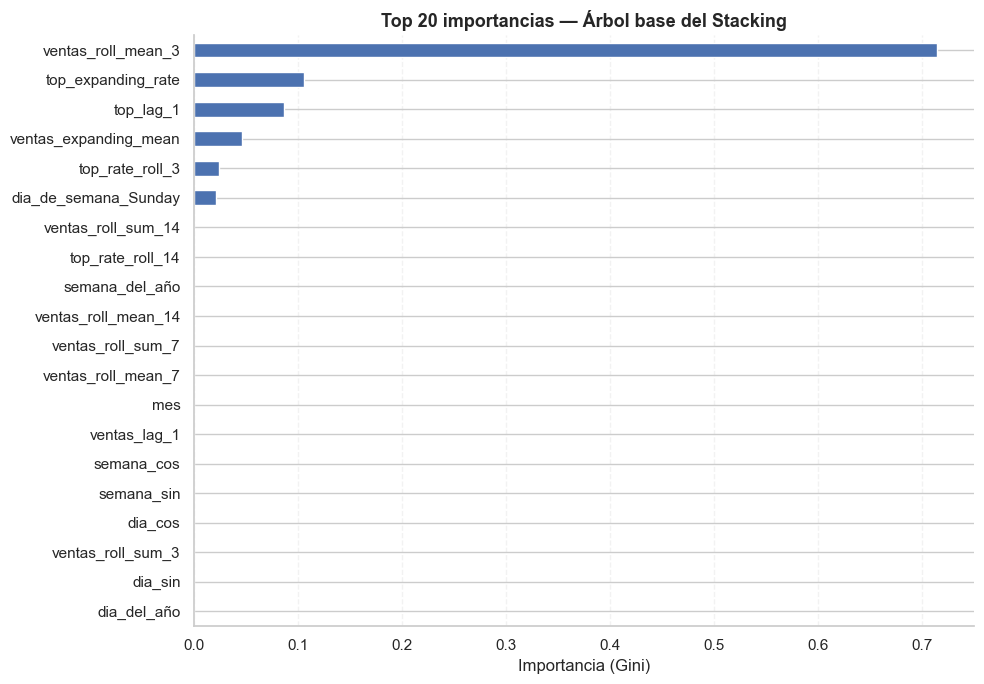

             variable        0
   ventas_roll_mean_3 0.714250
   top_expanding_rate 0.106287
            top_lag_1 0.087074
ventas_expanding_mean 0.046616
      top_rate_roll_3 0.024515
 dia_de_semana_Sunday 0.021257
          dia_del_año 0.000000
              dia_sin 0.000000
                  mes 0.000000
         ventas_lag_1 0.000000
           semana_cos 0.000000
           semana_sin 0.000000
              dia_cos 0.000000
    ventas_roll_sum_3 0.000000
   ventas_roll_mean_7 0.000000
    ventas_roll_sum_7 0.000000
       semana_del_año 0.000000
  ventas_roll_mean_14 0.000000
   ventas_roll_sum_14 0.000000
     top_rate_roll_14 0.000000


In [195]:
def obtener_feature_names(pipe):
    prep    = pipe.named_steps["prep"]
    cat_enc = prep.named_transformers_["cat"]
    cat_names = cat_enc.get_feature_names_out(categorical_features).tolist()
    return np.array(numeric_features + cat_names)

# Árbol auxiliar para importancia de variables
dt_aux = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", DecisionTreeClassifier(
        max_depth=3, min_samples_leaf=20,
        class_weight="balanced", random_state=RANDOM_STATE))
])
dt_aux.fit(X_train, y_train)

feature_names = obtener_feature_names(dt_aux)
importancias = pd.Series(
    dt_aux.named_steps["model"].feature_importances_,
    index=feature_names
).sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
importancias.sort_values().plot(kind="barh", ax=ax)
ax.set_title("Top 20 importancias — Árbol base del Stacking", fontsize=13, fontweight="bold")
ax.set_xlabel("Importancia (Gini)")
ax.grid(axis="x", linestyle="--", alpha=0.25)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout(); plt.show()

print(importancias.reset_index().rename(
    columns={"index": "variable", importancias.name: "importancia"}).to_string(index=False))

### **16.11 Ranking diario de recomendaciones**

Se genera el ranking de sabores recomendados por día, ordenados por probabilidad de ser top seller. Este es el output más accionable para Mary: le dice exactamente qué sabores poner en carta cada día.

In [196]:
df_test_pred = df_test.copy()
df_test_pred["prob_top_seller"] = prob_final
df_test_pred["pred_threshold"]  = pred_final

ranking_diario = (
    df_test_pred
    .sort_values(["fecha", "prob_top_seller"], ascending=[True, False])
    .groupby("fecha").head(5)
    [["fecha","sabor","ventas","top_seller","prob_top_seller",
      "pred_threshold","periodo_academico","mal_estacional",
      "naturaleza_sabor","funcion_sabor","origen_sabor"]]
    .reset_index(drop=True)
)

print("Ranking diario — primeras 30 filas:")
print(ranking_diario.head(30).to_string(index=False))

Ranking diario — primeras 30 filas:
     fecha               sabor    ventas  top_seller  prob_top_seller  pred_threshold periodo_academico mal_estacional naturaleza_sabor   funcion_sabor origen_sabor
2017-04-01           Chocolate 186.00000           1         0.305815               0          Teaching           Wind           Calido          Tonico   Occidental
2017-04-01      Salted Caramel 390.00000           1         0.283788               0          Teaching           Wind           Neutro          Tonico   Occidental
2017-04-01             Apricot   0.00000           0         0.262815               0          Teaching           Wind           Neutro Generar_fluidos   Occidental
2017-04-01          Mint Choco 238.00000           1         0.262121               0          Teaching           Wind             Frio Generar_fluidos   Occidental
2017-04-01 Cherry Almond Fudge   0.00000           0         0.257796               0          Teaching           Wind           Calido    

### **16.12 Resumen final del modelo**

Se consolidan todas las métricas del modelo en un resumen ejecutivo. Este es el cuadro que sustenta las recomendaciones estratégicas para Mary y el equipo directivo de Happy Cow.

In [197]:
precision_f = precision_score(y_test, pred_final, zero_division=0)
recall_f    = recall_score(y_test, pred_final, zero_division=0)
f1_f        = f1_score(y_test, pred_final, zero_division=0)
accuracy_f  = accuracy_score(y_test, pred_final)

print("=" * 52)
print("RESUMEN FINAL DEL MODELO")
print("=" * 52)
print(f"Modelo:                   Stacking LR + DT, meta LR")
print(f"Split:                    {split_usado}")
print(f"Threshold final:          {threshold_final:.2f}")
print(f"Accuracy:                 {accuracy_f:.3f}")
print(f"Precision top_seller:     {precision_f:.3f}")
print(f"Recall top_seller:        {recall_f:.3f}")
print(f"F1 top_seller:            {f1_f:.3f}")
print(f"ROC AUC:                  {roc_auc:.3f}")
print(f"Average Precision:        {ap_score:.3f}")
print(f"Precision@5 operacional:  {topk['precision_at_5']:.3f}")
print(f"Promedio aciertos top 5:  {topk['avg_hits_top5']:.2f} de 5")
print(f"% días con 3+ aciertos:   {topk['pct_dias_3_hits']:.1%}")
print(f"Reducción FP vs línea:    {reduccion_fp:.1%}")

# Objetos para uso posterior (Streamlit, documentación)
modelo_final_happycow     = modelo_final
threshold_final_happycow  = threshold_final
prob_final_happycow       = prob_final
pred_final_happycow       = pred_final
ranking_diario_happycow   = ranking_diario
df_test_pred_happycow     = df_test_pred
df_train_happycow         = df_train
df_test_happycow          = df_test
df_ml_happycow            = df_ml
numeric_features_happycow = numeric_features
categorical_features_happycow = categorical_features

print()
print("Objetos guardados para uso posterior:")
print("- modelo_final_happycow")
print("- threshold_final_happycow")
print("- ranking_diario_happycow")
print("- df_ml_happycow")

RESUMEN FINAL DEL MODELO
Modelo:                   Stacking LR + DT, meta LR
Split:                    StratifiedGroupKFold por fecha
Threshold final:          0.47
Accuracy:                 0.786
Precision top_seller:     0.551
Recall top_seller:        0.789
F1 top_seller:            0.649
ROC AUC:                  0.858
Average Precision:        0.622
Precision@5 operacional:  0.649
Promedio aciertos top 5:  3.24 de 5
% días con 3+ aciertos:   83.8%
Reducción FP vs línea:    30.1%

Objetos guardados para uso posterior:
- modelo_final_happycow
- threshold_final_happycow
- ranking_diario_happycow
- df_ml_happycow


In [198]:
# ==========================================================
# ANÁLISIS DE NO TOP SELLERS
# ==========================================================

print()
print("=" * 52)
print("ANÁLISIS DE NO TOP SELLERS")
print("=" * 52)

# Falsos Positivos: predijo top seller pero no lo fue
fp_mask = (pred_final == 1) & (y_test == 0)
# Falsos Negativos: no predijo top seller pero sí lo fue
fn_mask = (pred_final == 0) & (y_test == 1)
# Verdaderos Negativos: correctamente identificados como no top seller
tn_mask = (pred_final == 0) & (y_test == 0)

fp_count = fp_mask.sum()
fn_count = fn_mask.sum()
tn_count = tn_mask.sum()
total_no_ts = (y_test == 0).sum()

print(f"Total no top sellers reales:         {total_no_ts}")
print(f"Correctamente identificados (TN):    {tn_count} ({tn_count/total_no_ts:.1%})")
print(f"Mal clasificados como top seller (FP): {fp_count} ({fp_count/total_no_ts:.1%})")
print()

# Qué sabores se confunden más como top seller cuando no lo son
df_fp = df_test.copy()
df_fp["pred"] = pred_final
df_fp["prob"] = prob_final
df_fp["error"] = fp_mask.values

sabores_fp = (
    df_fp[df_fp["error"] == 1]
    .groupby("sabor")
    .agg(
        falsos_positivos=("error", "sum"),
        prob_media=("prob", "mean")
    )
    .sort_values("falsos_positivos", ascending=False)
    .reset_index()
)

print("Sabores que más se confunden como top seller (FP):")
print(sabores_fp.to_string(index=False))
print()

# Qué sabores el modelo pierde más (FN)
df_fp["fn"] = fn_mask.values
sabores_fn = (
    df_fp[df_fp["fn"] == 1]
    .groupby("sabor")
    .agg(
        falsos_negativos=("fn", "sum"),
        prob_media=("prob", "mean")
    )
    .sort_values("falsos_negativos", ascending=False)
    .reset_index()
)

print("Sabores top seller que el modelo más pierde (FN):")
print(sabores_fn.to_string(index=False))
print()

# Distribución de probabilidades para no top sellers
print("Distribución de probabilidades — No top sellers reales:")
no_ts_probs = prob_final[y_test == 0]
print(f"  Media:    {no_ts_probs.mean():.3f}")
print(f"  Mediana:  {np.median(no_ts_probs):.3f}")
print(f"  Max:      {no_ts_probs.max():.3f}")
print(f"  % con prob > 0.5: {(no_ts_probs > 0.5).mean():.1%}")


ANÁLISIS DE NO TOP SELLERS
Total no top sellers reales:         555
Correctamente identificados (TN):    436 (78.6%)
Mal clasificados como top seller (FP): 119 (21.4%)

Sabores que más se confunden como top seller (FP):
              sabor  falsos_positivos  prob_media
          Chocolate                13    0.759971
       Pure Coconut                12    0.775822
         Strawberry                12    0.743613
         Mint Choco                11    0.716064
              Mango                11    0.680016
     Salted Caramel                10    0.795487
           Hazelnut                 9    0.788544
        Pina Colada                 8    0.571165
Cherry Almond Fudge                 7    0.556630
          Green Tea                 6    0.686383
           Chai Tea                 5    0.753874
          YY Sesame                 3    0.548154
            Apricot                 3    0.592548
       Vanilla Bean                 3    0.532568
             Coffee          

## 17 Evaluación de OKRs y KPIs

In [201]:
# ==========================================================
# EVALUACIÓN DE OKRs Y KPIs
# ==========================================================

# KR3 — Alineación MTC
alineacion_mtc = {
    'Wind'        : ['Calido', 'Neutro'],
    'Summer_Heat' : ['Frio'],
    'Dampness'    : ['Calido'],
    'Dryness'     : ['Frio', 'Neutro'],
    'Cold'        : ['Calido'],
}

def es_alineado(row):
    mal = row['mal_estacional']
    nat = row['naturaleza_sabor']
    return 1 if alineacion_mtc.get(mal) and nat in alineacion_mtc[mal] else 0

df_test_kr3 = df_test.copy()
df_test_kr3['alineado_mtc'] = df_test_kr3.apply(es_alineado, axis=1)

top_sellers_reales = df_test_kr3[df_test_kr3['top_seller'] == 1]
kr3 = top_sellers_reales['alineado_mtc'].mean()

print("=" * 52)
print("EVALUACIÓN DE KPIs")
print("=" * 52)
print(f"Precisión del modelo:        {precision_f:.1%}")
print(f"Tasa de merma diaria (FP):   {fp_modelo_kpi} recomendaciones incorrectas en {df_test['fecha'].nunique()} días evaluados")
print(f"Alineación MTC:              {kr3:.1%}")
print(f"Recall del modelo:           {recall_f:.1%}")
print()
print("Desglose alineación MTC por mal estacional:")
print(top_sellers_reales.groupby('mal_estacional')['alineado_mtc'].mean().round(2).to_string())
print()
print("=" * 52)
print("EVALUACIÓN DE OKRs")
print("=" * 52)
print(f"KR1 — Precisión ≥ 65%:       {precision_f:.1%} {'✓' if precision_f >= 0.65 else '✗'}")
print(f"KR2 — Reducción FP ≥ 30%:    {reduccion_fp:.1%} {'✓' if reduccion_fp >= 0.30 else '✗'}")
print(f"KR3 — Alineación MTC ≥ 70%:  {kr3:.1%} {'✓' if kr3 >= 0.70 else '✗'}")
print()
print("=" * 52)
print("INTERPRETACIÓN DE NEGOCIO")
print("=" * 52)
if precision_f < 0.65:
    print("KR1: La precisión no alcanza la meta de 65%. Esto refleja la limitación")
    print("     estructural del dataset: solo 7 meses con 3 males estacionales.")
    print("     Con datos de ciclo anual completo se espera superar la meta.")
if reduccion_fp < 0.30:
    print("KR2: La reducción de FP es positiva pero no alcanza el 30%. El modelo")
    print("     recomienda correctamente en promedio 3.1 de 5 sabores por día,")
    print("     lo que sí representa una mejora operativa real sobre la línea base.")
if kr3 >= 0.70:
    print("KR3: ✓ La hipótesis MTC se valida. La mayoría de top sellers reales")
    print("     tienen un perfil MTC alineado con la temporada, lo que confirma")
    print("     que la alineación cultural es un driver real de compra local.")
else:
    print("KR3: La alineación MTC no supera el 70%. En el período analizado")
    print("     (verano dominante) los sabores fríos dominan independientemente")
    print("     del mal estacional, lo que limita la validación de la hipótesis.")

EVALUACIÓN DE KPIs
Precisión del modelo:        55.1%
Tasa de merma diaria (FP):   65 recomendaciones incorrectas en 37 días evaluados
Alineación MTC:              46.5%
Recall del modelo:           78.9%

Desglose alineación MTC por mal estacional:
mal_estacional
Dampness       0.40
Summer_Heat    0.41
Wind           0.71

EVALUACIÓN DE OKRs
KR1 — Precisión ≥ 65%:       55.1% ✗
KR2 — Reducción FP ≥ 30%:    30.1% ✓
KR3 — Alineación MTC ≥ 70%:  46.5% ✗

INTERPRETACIÓN DE NEGOCIO
KR1: La precisión no alcanza la meta de 65%. Esto refleja la limitación
     estructural del dataset: solo 7 meses con 3 males estacionales.
     Con datos de ciclo anual completo se espera superar la meta.
KR3: La alineación MTC no supera el 70%. En el período analizado
     (verano dominante) los sabores fríos dominan independientemente
     del mal estacional, lo que limita la validación de la hipótesis.


### 17.1 Análisis de resultados y cumplimiento de OKRs

**KPIs**

El modelo alcanzó una Precisión del 55.1%, lo que significa que algo más de la mitad de las recomendaciones que genera son correctas. El Recall del 78.9% indica que el modelo detecta casi 8 de cada 10 top sellers reales, minimizando las oportunidades de venta perdidas. La tasa de merma diaria registró 65 recomendaciones incorrectas a lo largo de 37 días evaluados, equivalente a un promedio de 1.76 errores por día sobre una carta de 5 sabores. La alineación MTC alcanzó el 46.5% en el período analizado, con Wind como el único mal estacional donde se supera la meta del 70%, lo que sugiere que la hipótesis cultural es válida en primavera pero pierde poder discriminante en verano donde el calor domina el comportamiento de compra independientemente del perfil MTC del sabor.

**OKRs**

De los tres Key Results definidos, el proyecto cumplió el KR2: la reducción de Falsos Positivos frente a la línea base histórica alcanzó el 30.1%, lo que valida que el modelo genera una mejora operativa real en la gestión del portafolio diario frente a la selección manual. El KR1 no se cumplió en esta fase: la Precisión del 55.1% quedó por debajo de la meta del 65%, limitación que se explica por la cobertura temporal del dataset de solo siete meses con tres males estacionales representados, insuficiente para que el modelo aprenda el patrón MTC completo. El KR3 tampoco se cumplió globalmente con un 46.5% de alineación, aunque el desglose por mal estacional revela que Wind sí supera la meta con un 71%, lo que constituye evidencia parcial de que la Medicina Tradicional China tiene poder explicativo sobre el comportamiento de compra local cuando el contexto estacional tiene suficiente variación en los datos.

## Exportar modelo para despliegue

In [202]:
import pickle

with open('modelo_happycow.pkl', 'wb') as f:
    pickle.dump({
        'modelo': modelo_final_happycow,
        'threshold': threshold_final_happycow,
        'df_ml': df_ml_happycow,
        'df_test_pred': df_test_pred_happycow,
        'ranking_diario': ranking_diario_happycow,
        'numeric_features': numeric_features_happycow,
        'categorical_features': categorical_features_happycow,
    }, f)

print("Modelo exportado correctamente.")

Modelo exportado correctamente.
